# Mini Project Visualisasi Data & EDA
Dataset: bike_buyers\
By: Daffa Aryo Utomo Sudranto\
Bootcamp Program: Dibimbing.id Data Analyst 3 Offline

## **Deskripsi Kolom Dataset Bike Buyers**
---
- **ID**              : Identitas (unik) untuk setiap responden dalam dataset
- **Marital Status**  : Status pernikahan responden
- **Gender**          : Jenis kelamin responden
- **Income**          : Pendapatan tahunan responden
- **Children**        : Jumlah anak yang dimiliki oleh responden
- **Education**       : Tingkat pendidikan terakhir responden
- **Occupation**      : Kategori pekerjaan responden
- **Home Owner**      : Status kepemilikan rumah
- **Cars**            : Jumlah kendaraan (mobil) yang dimiliki responden
- **Commute Distance**: Jarak tempuh perjalanan responden dari rumah ke tempat kerja
- **Region**          : Wilayah atau daerah tempat tinggal responden
- **Age**             : Usia responden dalam satuan tahun
- **Purchased Bike**  : Kolom target yang menunjukkan apakah responden membeli sepeda atau tidak

In [185]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import shapiro
from scipy import stats
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from scipy.stats import spearmanr
import plotly.express as px

## **1. Import dan Eksplorasi Data**

In [186]:
# Import data
df = pd.read_csv("C:\Dibimbing\Python\Dataset\\bike_buyers.csv")
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [187]:
# Periksa jumlah row dan kolom
df.shape

(1000, 13)

Row: 1000

Kolom: 13

In [188]:
# Periksa nama kolom
df.columns

Index(['ID', 'Marital Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age',
       'Purchased Bike'],
      dtype='object')

In [189]:
# Periksa tipe data tiap kolom
df.dtypes

ID                    int64
Marital Status       object
Gender               object
Income              float64
Children            float64
Education            object
Occupation           object
Home Owner           object
Cars                float64
Commute Distance     object
Region               object
Age                 float64
Purchased Bike       object
dtype: object

In [190]:
# summary informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


In [191]:
# Periksa nilai statistik dasar untuk kolom numerik
df.describe()

,ID,Income,Children,Cars,Age
count,1000.000000,994.000000,992.000000,991.000000,992.000000
mean,19965.992000,56267.605634,1.910282,1.455096,44.181452
std,5347.333948,31067.817462,1.626910,1.121755,11.362007
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


In [192]:
# Periksa nilai statistik dasar untuk kolom object
df.describe(include=["object"])

,Marital Status,Gender,Education,Occupation,Home Owner,Commute Distance,Region,Purchased Bike
count,993,989,1000,1000,996,1000,1000,1000
unique,2,2,5,5,2,5,3,2
top,Married,Male,Bachelors,Professional,Yes,0-1 Miles,North America,No
freq,535,500,306,276,682,366,508,519


In [193]:
# Membuat tabel informasi unique value kolom object
obj_col = df.select_dtypes(include=["object"]).columns # variable untuk mengambil nama kolom object
obj_value = []

# membuat dictionary untuk tabel unique value
for col in obj_col:
    obj_value.append({
        "column_name" : col, #nama kolom
        "unique_value" : df[col].dropna().unique().tolist(), # list unique value 
        "n_unique" : df[col].nunique(dropna=True) # jumlah unique value
    })

# membuat data frame dari dictionary unique value
df_obj_value = pd.DataFrame(obj_value)

# Menampilkan seluruh kolom dataframe
pd.set_option("display.max_colwidth", None) # Menampilkan seluruh kolom dataframe
df_obj_value

,column_name,unique_value,n_unique
0,Marital Status,"[Married, Single]",2
1,Gender,"[Female, Male]",2
2,Education,"[Bachelors, Partial College, High School, Partial High School, Graduate Degree]",5
3,Occupation,"[Skilled Manual, Clerical, Professional, Manual, Management]",5
4,Home Owner,"[Yes, No]",2
5,Commute Distance,"[0-1 Miles, 2-5 Miles, 5-10 Miles, 1-2 Miles, 10+ Miles]",5
6,Region,"[Europe, Pacific, North America]",3
7,Purchased Bike,"[No, Yes]",2


In [194]:
# Setting warna visualisasi global
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"

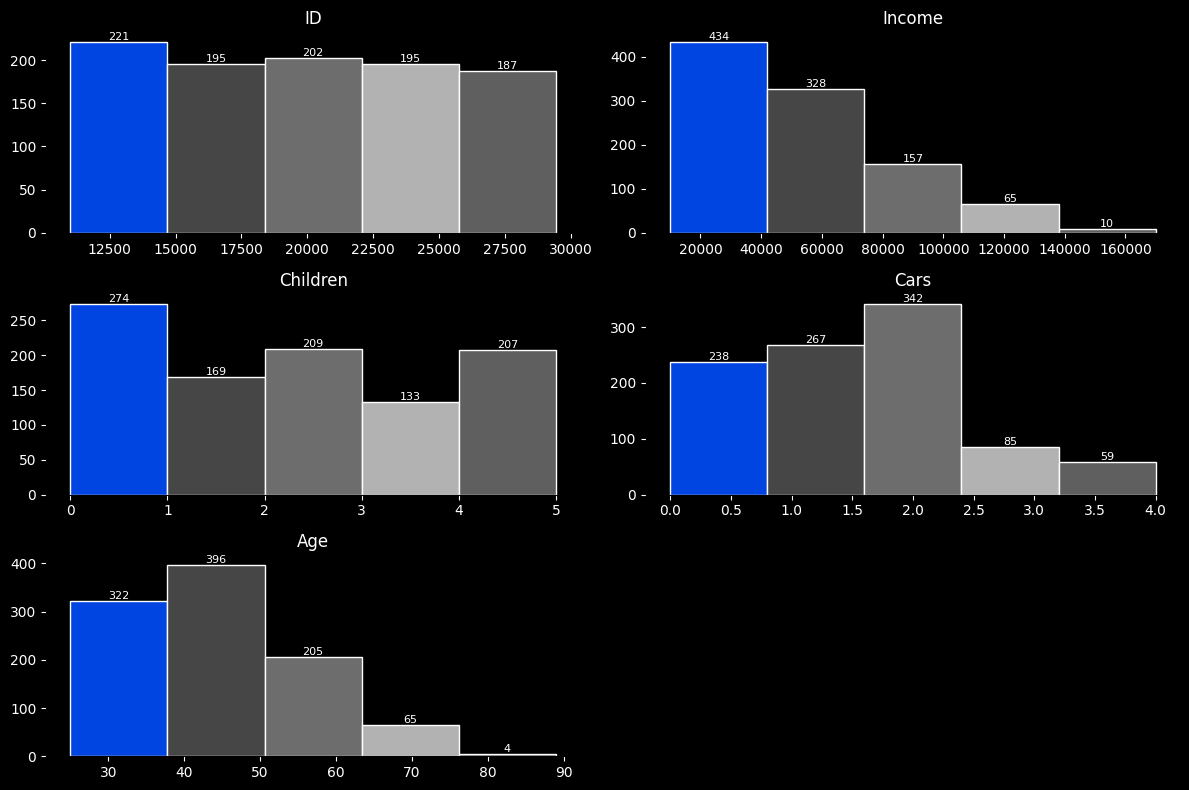

In [195]:
axes = df.select_dtypes(include="number").hist(
    bins=5,
    figsize=(12,8),
    edgecolor="white",
    grid=False
)

colors = ["#0045e1", "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]

axes = np.array(axes).reshape(-1)

for ax in axes:
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()

        # ✅ kasih warna ke tiap bar
        patch.set_facecolor(colors[i % len(colors)])

        # ✅ kasih angka
        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width()/2,
                height,
                int(height),
                ha='center',
                va='bottom',
                fontsize=8,
                color='white'
            )

plt.tight_layout()
plt.show()

In [196]:
# Menampilkan dataframe untuk missing value/data hilang
df_na = pd.DataFrame({
    "missing_value" : df.isna().sum(), # jumlah missing value per kolom
    "percentage(%)" : round((df.isna().mean()*100),2) # persentase missing value per kolom
})
print(df_na.sort_values(by="missing_value", ascending=False)[df_na["missing_value"]>0])
print("\n")
print("Jumlah missing value: ",df_na["missing_value"].sum()) # jumlah missing value keseluruhan
print("Persentase missing value (%): ",round((df_na["percentage(%)"].sum()),2)) # peresentase missing value keseluruhan

                missing_value  percentage(%)
Gender                     11            1.1
Cars                        9            0.9
Children                    8            0.8
Age                         8            0.8
Marital Status              7            0.7
Income                      6            0.6
Home Owner                  4            0.4


Jumlah missing value:  53
Persentase missing value (%):  5.3


C:\Users\daryo\AppData\Local\Temp\ipykernel_33704\663209571.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_na.sort_values(by="missing_value", ascending=False)[df_na["missing_value"]>0])


In [197]:
for n in obj_col:
    print(f"{df[n].value_counts()}") # jumlah count data pada value
    print(f"{(df[n].value_counts()/len(df))*100}") # komposisi value
    print('\n') # sebagai spasi antar data kolom


Marital Status
Married    535
Single     458
Name: count, dtype: int64
Marital Status
Married    53.5
Single     45.8
Name: count, dtype: float64


Gender
Male      500
Female    489
Name: count, dtype: int64
Gender
Male      50.0
Female    48.9
Name: count, dtype: float64


Education
Bachelors              306
Partial College        265
High School            179
Graduate Degree        174
Partial High School     76
Name: count, dtype: int64
Education
Bachelors              30.6
Partial College        26.5
High School            17.9
Graduate Degree        17.4
Partial High School     7.6
Name: count, dtype: float64


Occupation
Professional      276
Skilled Manual    255
Clerical          177
Management        173
Manual            119
Name: count, dtype: int64
Occupation
Professional      27.6
Skilled Manual    25.5
Clerical          17.7
Management        17.3
Manual            11.9
Name: count, dtype: float64


Home Owner
Yes    682
No     314
Name: count, dtype: int64
Home Owner


## **2. Data Cleaning & Handling**

In [198]:
# variable copy dari data mentah untuk proses cleaning dan manipulasi
dfc = df.copy() # dfc (Data Frame Clean)
dfc.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [199]:
# Penamaan kembali untuk kolom dataset
kolombaru = []
for i in dfc.columns:
    kolombaru.append(i.strip().replace(" ", "_")) # menghapus spasi tersembunyi dan merubah spasi antar kata dengan underscore (_)

dfc.columns = kolombaru
print(dfc.columns)

Index(['ID', 'Marital_Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home_Owner', 'Cars', 'Commute_Distance', 'Region', 'Age',
       'Purchased_Bike'],
      dtype='object')


In [200]:
# Mengisi data gender yang kosong dengan kategori baru "Unknown"
dfc["Gender"].fillna("Unknown", inplace=True)

C:\Users\daryo\AppData\Local\Temp\ipykernel_33704\1126010537.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfc["Gender"].fillna("Unknown", inplace=True)


In [201]:
# Perbandingan sebelum dan sesudah pengisian missing value pada kolom Gender
print("Before:")
print(f"{df['Gender'].value_counts()}")
print(f"{(df['Gender'].value_counts()/len(df))*100}")
print("\n")
print("After:")
print(f"{dfc['Gender'].value_counts()}")

print(f"{(dfc['Gender'].value_counts()/len(dfc))*100}")

Before:
Gender
Male      500
Female    489
Name: count, dtype: int64
Gender
Male      50.0
Female    48.9
Name: count, dtype: float64


After:
Gender
Male       500
Female     489
Unknown     11
Name: count, dtype: int64
Gender
Male       50.0
Female     48.9
Unknown     1.1
Name: count, dtype: float64


In [202]:
# Menampilkan jumlah dan komposisi tiap kategori Marital_Status yang memiliki rumah
status_home = dfc[dfc['Home_Owner'] == 'Yes'].groupby("Marital_Status").agg(count=("ID", "count"))
status_home["percentage"] = (status_home["count"]/len(dfc[dfc["Home_Owner"]=="Yes"])*100).round(2)
status_home

,count,percentage
Marital_Status,,
Married,438,64.22
Single,240,35.19


In [203]:
# Mengisi missing value pada kolom Marital_Status
dfc.loc[(dfc["Marital_Status"].isnull()) & (dfc["Home_Owner"] == "Yes"), "Marital_Status"] = "Married" # Jika memiliki rumah, diisi dengan Married
dfc.loc[(dfc["Marital_Status"].isnull()) & (dfc["Home_Owner"] == "No"), "Marital_Status"] = "Single" # Jika tidak memiliki rumah, diisi dengan Single

In [204]:
# Perbandingan sebelum dan sesudah pengisian missing value pada kolom Marital_Status
print("Before:")
print(f"{df['Marital Status'].value_counts()}")
print(f"{(df['Marital Status'].value_counts()/len(df))*100}")
print("\n")
print("After:")
print(f"{dfc['Marital_Status'].value_counts()}")
print(f"{(dfc['Marital_Status'].value_counts()/len(dfc))*100}")

Before:
Marital Status
Married    535
Single     458
Name: count, dtype: int64
Marital Status
Married    53.5
Single     45.8
Name: count, dtype: float64


After:
Marital_Status
Married    539
Single     461
Name: count, dtype: int64
Marital_Status
Married    53.9
Single     46.1
Name: count, dtype: float64


In [205]:
# Menampilkan jumlah dan komposisi tiap kategori Home_Owner yang memiliki anak
home_child = dfc[dfc['Children'] > 0].groupby("Home_Owner").agg(count=("ID", "count")) 
home_child["percentage"] = (home_child["count"]/len(dfc[dfc['Children'] > 0])*100).round(2)
home_child.sort_values(by='percentage', ascending=False)

,count,percentage
Home_Owner,,
Yes,535,74.51
No,180,25.07


In [206]:
# Mengisi missing value pada kolom Home_owner
dfc.loc[(dfc["Home_Owner"].isnull()) & (dfc["Children"] > 0), "Home_Owner"] = "Yes" # Jika memiliki anak, diisi dengan Yes
dfc.loc[(dfc["Home_Owner"].isnull()) & (dfc["Children"] < 1), "Home_Owner"] = "No" # Jika tidak memiliki anak, diisi dengan No

In [207]:
# Perbandingan sebelum dan sesudah pengisian missing value pada kolom Home_Owner
print("Before:")
print(f"{df['Home Owner'].value_counts()}")
print(f"{(df['Home Owner'].value_counts()/len(df))*100}")
print("\n")
print("After:")
print(f"{dfc['Home_Owner'].value_counts()}")
print(f"{(dfc['Home_Owner'].value_counts()/len(dfc))*100}")

Before:
Home Owner
Yes    682
No     314
Name: count, dtype: int64
Home Owner
Yes    68.2
No     31.4
Name: count, dtype: float64


After:
Home_Owner
Yes    685
No     315
Name: count, dtype: int64
Home_Owner
Yes    68.5
No     31.5
Name: count, dtype: float64


In [208]:
# Mengambil nama kolom numerik
col_numeric = df.select_dtypes(include='number').columns[1:] # mengambil nama kolom dimulai dari index 1

# Mengisi missing value pada kolom numerik pada col_numeric dengan nilai median
for col in col_numeric:
    median_col = dfc[col].median()
    dfc[col] = dfc[col].fillna(median_col)

In [209]:
# Index kolom numerik
col_numeric

Index(['Income', 'Children', 'Cars', 'Age'], dtype='object')

In [210]:
# Menampilkan dataframe untuk missing value/data hilang dfc
dfc_na = pd.DataFrame({
    "missing_value" : dfc.isna().sum(),
    "percentage(%)" : round((dfc.isna().mean()*100),2)
})
print(dfc_na.sort_values(by="missing_value", ascending=False)[dfc_na["missing_value"]>0])
print("\n")
print("Jumlah missing value: ",dfc_na["missing_value"].sum())
print("Persentase missing value (%): ",round((dfc_na["percentage(%)"].sum()),2))

Empty DataFrame
Columns: [missing_value, percentage(%)]
Index: []


Jumlah missing value:  0
Persentase missing value (%):  0.0


In [211]:
print('===Statistik Dasar Dataframe sebelum cleaning===')
print(df.describe())
print('\n')
print('===Statistik Dasar Dataframe setelah cleaning===')
print(dfc.describe())

===Statistik Dasar Dataframe sebelum cleaning===
                 ID         Income    Children        Cars         Age
count   1000.000000     994.000000  992.000000  991.000000  992.000000
mean   19965.992000   56267.605634    1.910282    1.455096   44.181452
std     5347.333948   31067.817462    1.626910    1.121755   11.362007
min    11000.000000   10000.000000    0.000000    0.000000   25.000000
25%    15290.750000   30000.000000    0.000000    1.000000   35.000000
50%    19744.000000   60000.000000    2.000000    1.000000   43.000000
75%    24470.750000   70000.000000    3.000000    2.000000   52.000000
max    29447.000000  170000.000000    5.000000    4.000000   89.000000


===Statistik Dasar Dataframe setelah cleaning===
                 ID         Income     Children         Cars          Age
count   1000.000000    1000.000000  1000.000000  1000.000000  1000.000000
mean   19965.992000   56290.000000     1.911000     1.451000    44.172000
std     5347.333948   30975.722678     

In [212]:
# Membuat tabel pemeriksaan outlier
# Metode pemriksaan outlier: IQR
outlier_summary = {}

for n in col_numeric:
    Q1 = dfc[n].quantile(0.25) # Mendapatkan nilai 25% dari dataset
    Q3 = dfc[n].quantile(0.75) # Mendapatkan nilai 75% dari dataset
    IQR = Q3 - Q1

    lowerbond = Q1 - 1.5*IQR # Medapatkan nilai batas bawah outlier
    upperbond = Q3 + 1.5*IQR # Medapatkan nilai batas atas outlier

    outlier = dfc[(dfc[n] < lowerbond) | (dfc[n] > upperbond)] # outlier adalah nilai diatas nilai uppperbond atau dibawah lowerbond

    # Variable untuk merangkum perhitungan metode IQR dalam bentuk dictionary
    outlier_summary[n] = {
        "lower_bond" : lowerbond,
        "upper_bond" : upperbond,
        "n_outlier" : len(outlier), # jumlah data yang termasuk outlier
        "percentage" : len(outlier)/len(dfc[n])*100 # persentase
    }

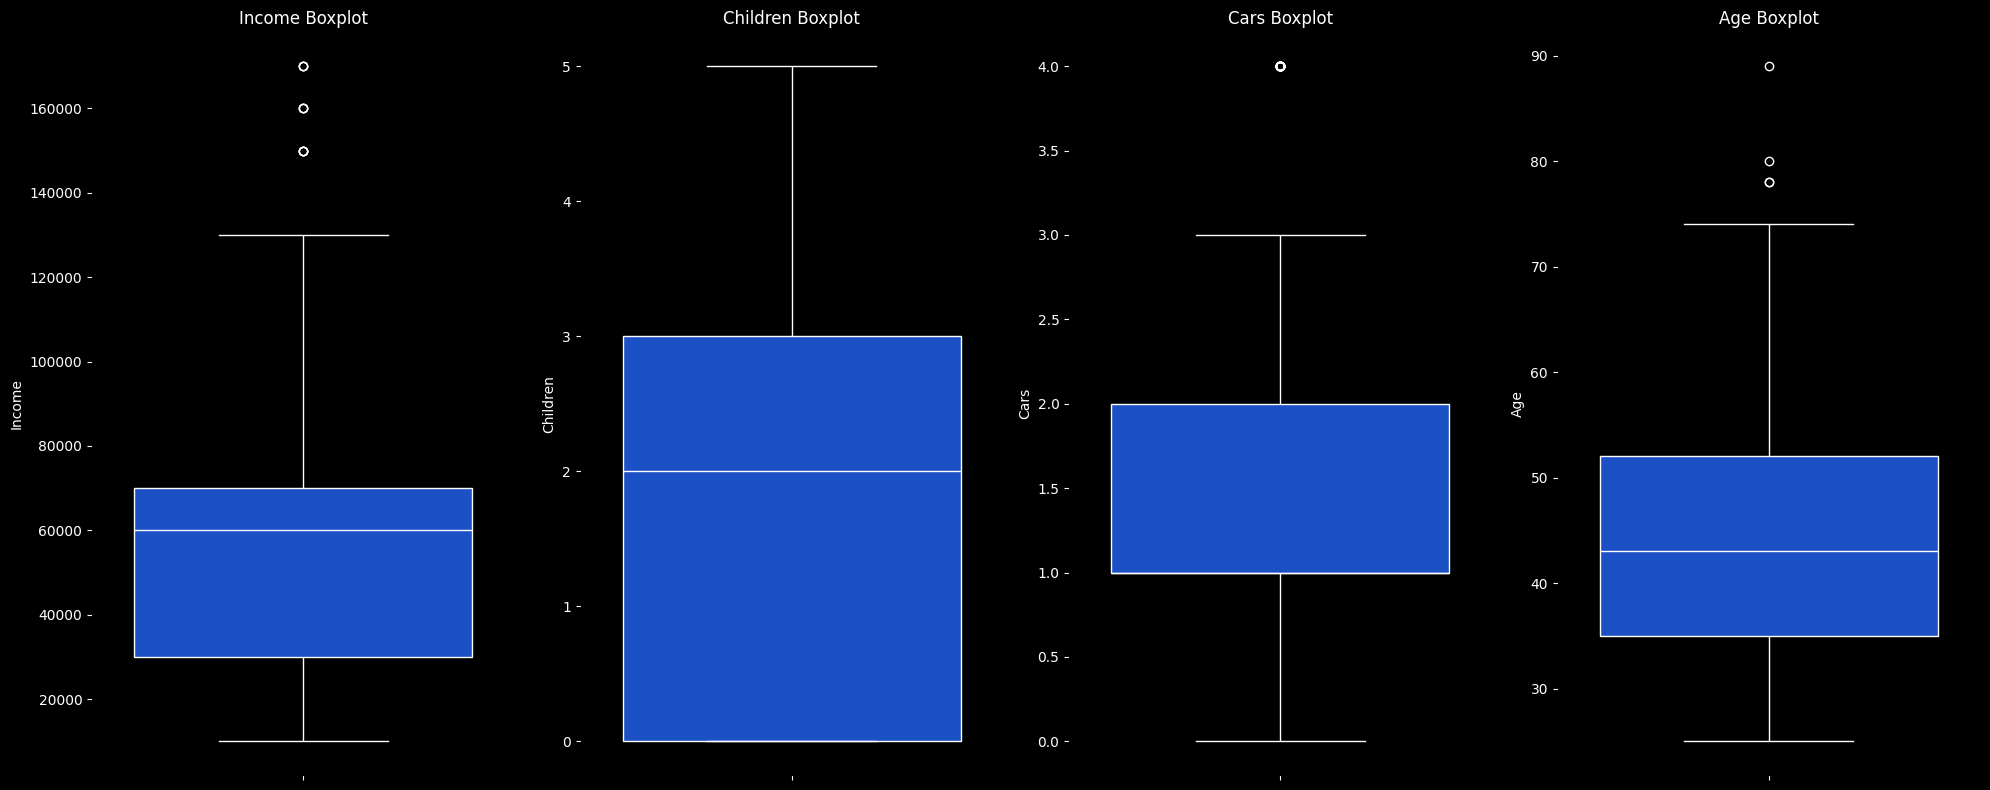

In [213]:
# Membuat subplot untuk boxplot outlier data numerik
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

# Boxplot 1: Income 
sns.boxplot(
    y=dfc["Income"], 
    ax=axes[0], 
    color="#0045e1", 
    linecolor='white'
    )
axes[0].set_title("Income Boxplot")

# Boxplot 2: Age
sns.boxplot(
    y=dfc["Children"], 
    ax=axes[1], 
    color="#0045e1",
    linecolor='white'
    ) 
axes[1].set_title("Children Boxplot") 

# Boxplot 3: Cars
sns.boxplot(
    y=dfc["Cars"], 
    ax=axes[2], 
    color="#0045e1",
    linecolor='white'
    ) 
axes[2].set_title("Cars Boxplot")

# Boxplot 4: Age
sns.boxplot(
    y=dfc["Age"], 
    ax=axes[3], 
    color="#0045e1",
    linecolor='white'
    ) 
axes[3].set_title("Age Boxplot")

plt.tight_layout()
plt.show()

- Terdapat outlier pada kolom Income, Cars, dan Age

In [214]:
# Menampilkan outlier_summary dalam bentuk Data Frame
pd.DataFrame(outlier_summary)

,Income,Children,Cars,Age
lower_bond,-30000.0,-4.5,-0.5,9.5
upper_bond,130000.0,7.5,3.5,77.5
n_outlier,10.0,0.0,59.0,4.0
percentage,1.0,0.0,5.9,0.4


Temuan:
- Ditemukan outlier pada kolom: Income, Cars, & Age
- seluruh outlier yang ditemukan tetap dipertahankan
- outlier dipetahankan karena untuk menggunakan nilai tersebut sebagai data yang diperlukan untuk insight bisnis

In [215]:
# Memeriksa duplikat
dfc.duplicated().sum()

np.int64(0)

- Tidak ditermukan duplikat

## 3. Data Manipulation

In [216]:
# variable nama kolom yang memiliki ketidak cocokan tipe data
correction_datatype = ['Children', 'Cars', 'Age']

# Mengubah tipe data kolom dari variable correction_datatype menjadi integer (int)
for c in correction_datatype:
    dfc[c] = dfc[c].astype(int)

In [217]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital_Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Children          1000 non-null   int64  
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home_Owner        1000 non-null   object 
 8   Cars              1000 non-null   int64  
 9   Commute_Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               1000 non-null   int64  
 12  Purchased_Bike    1000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 101.7+ KB


- Perubahan tipe data berhasil

## 4. Data Distribution

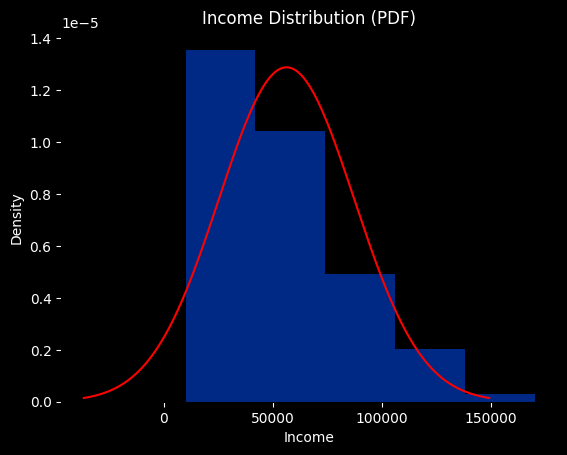

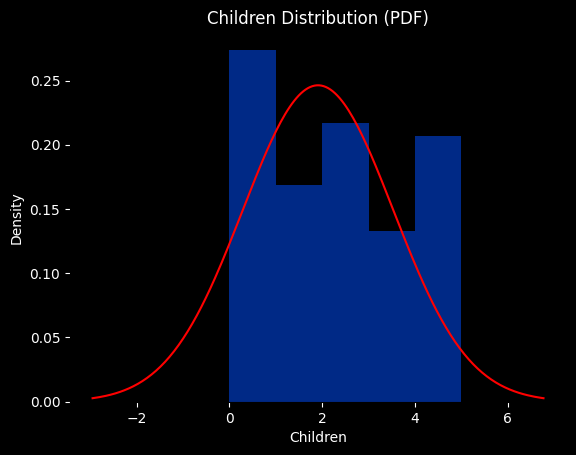

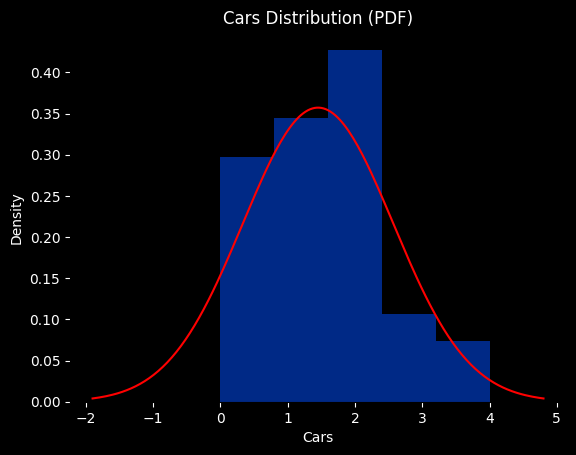

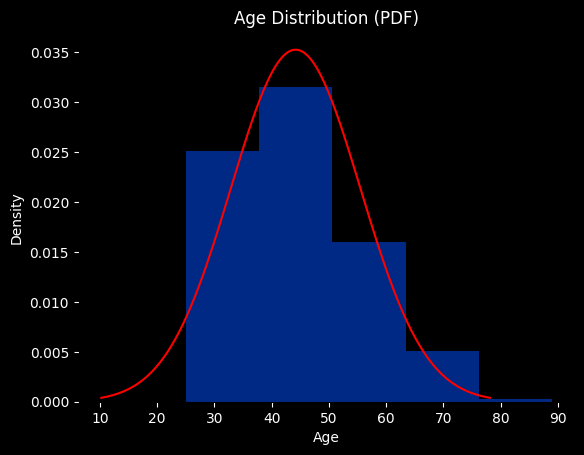

In [218]:
# Membuat garis normalitas
for col in col_numeric:
    mu = dfc[col].mean()
    sigma = np.std(dfc[col])
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200) 
    pdf = norm.pdf(x, mu, sigma)

    # Membuat histogram distribusi untuk setiap kolom numerik
    plt.hist(
        dfc[col], 
        bins = 5, 
        density=True, 
        alpha=0.6,
        color= "#0045e1"
        )
    plt.plot(
        x, 
        pdf, 
        color='red'
        )
    
    plt.title(f"{col} Distribution (PDF)")
    plt.xlabel(f"{col}")
    plt.ylabel("Density")
    plt.show()

Temuan:
- kolom Income: bentuk cenderung right-skewed (Kerapatan cenderung disebelah kiri)
- kolom Children: bentuk cenderung Uniform/simtris (Kerapatan cenderung merata, namun tinggi bagian paling kiri dan paling kanan)
- kolom Cars: bentuk cenderung right-skewed (Kerapatan cenderung disebelah kiri)
- kolom age: bentuk cenderung right-skewed (Kerapatan cenderung disebelah kiri)

## 5. Feature Engineering

In [219]:
# Kategori untuk kolom baru: "Income_Category"
def income_category(income):
    if income <= 40000:
        return "Low" # jika pendapatan dibawah atau sama dengan 40.000, Kategori pendatan rendah
    elif income <= 70000:
        return "Middle" # jika pendapatan dibawah atau sama dengan 70.000, Kategori pendatan menengah
    elif income <= 110000:
        return "High" # jika pendapatan dibawah atau sama dengan 110.000, Kategori pendatan tinggi
    else:
        return "Ultra High" # jika pendapatan diatas 110.000, Kategori pendatan sangat tinggi

In [220]:
# Membuat kolom baru "Income_Category"
dfc["Income_Category"] = dfc["Income"].apply(income_category)

In [221]:
# Kategori untuk kolom baru: "Age_Group"
def age_group(age):
    if age <= 30:
        return "Young Adult" # jika umur dibawah atau sama dengan 30 tahun, kelompok umur pemuda
    elif age <= 50:
        return "Middle Aged" # jika umur dibawah atau sama dengan 50 tahun, kelompok umur setengah baya
    elif age <= 70:
        return "Senior" # jika umur dibawah atau sama dengan 70 tahun, kelompok umur senior
    else:
        return "Old" # jika umur diatas 70 tahun, kelompok setengah orang tua / lanjut usia (lansia)

In [222]:
# Membuat kolom baru "Age_Group"
dfc['Age_Group'] = dfc['Age'].apply(age_group)

In [223]:
# Kategori untuk kolom baru: "Having_Children"
def having_child(child):
    if child == 0:
        return "No" # Jika jumlah anak sama dengan 0, maka tidak punya anak
    else:
        return "Yes" # Jika jumlah anak lebih dari 0, maka punya anak

In [224]:
# Membuat kolom baru "Having_Children"
dfc['Having_Children'] = dfc['Children'].apply(having_child)

In [225]:
# Kategori untuk kolom baru: "Car_Owner"
def car_owner(car):
    if car == 0:
        return "No" # Jika jumlah mobil sama dengan 0, maka tidak punya mobil
    else:
        return "Yes" # Jika jumlah mobil lebih dari 0, maka punya mobil

In [226]:
# Membuat kolom baru "Car_Owner"
dfc['Car_Owner'] = dfc['Cars'].apply(car_owner)

In [227]:
# Mengurutkan nama kolom dataframe
dfc = dfc[['ID', 'Marital_Status', 'Gender',
           'Income', 'Income_Category', 'Children', 'Having_Children', 'Education',
           'Occupation', 'Home_Owner', 'Cars', 'Car_Owner', 'Commute_Distance',
           'Region', 'Age', 'Age_Group', 'Purchased_Bike']]

In [228]:
# Periksa urutan kolom dfc
dfc.head(0)

,ID,Marital_Status,Gender,Income,Income_Category,Children,Having_Children,Education,Occupation,Home_Owner,Cars,Car_Owner,Commute_Distance,Region,Age,Age_Group,Purchased_Bike


## 6. Data Exploration (Data Clean)

In [229]:
# Membuat dataset sample (20% dari data clean)
sampledfc = dfc.sample(frac=0.2, random_state=42) # Mengambil 20% data dfc dan mengunci data acak yang diambil
sampledfc.head()

,ID,Marital_Status,Gender,Income,Income_Category,Children,Having_Children,Education,Occupation,Home_Owner,Cars,Car_Owner,Commute_Distance,Region,Age,Age_Group,Purchased_Bike
521,18976,Single,Male,40000.0,Low,4,Yes,High School,Professional,Yes,2,Yes,10+ Miles,North America,62,Senior,Yes
737,18504,Married,Male,70000.0,Middle,2,Yes,Partial High School,Skilled Manual,No,2,Yes,1-2 Miles,North America,49,Middle Aged,No
740,17657,Married,Male,40000.0,Low,4,Yes,Partial College,Clerical,No,0,No,0-1 Miles,North America,30,Young Adult,No
660,21599,Married,Female,60000.0,Middle,1,Yes,Graduate Degree,Professional,Yes,0,No,2-5 Miles,North America,36,Middle Aged,Yes
411,11116,Married,Male,70000.0,Middle,5,Yes,Partial College,Skilled Manual,Yes,2,Yes,5-10 Miles,Pacific,43,Middle Aged,No


In [230]:
dfc.head()

,ID,Marital_Status,Gender,Income,Income_Category,Children,Having_Children,Education,Occupation,Home_Owner,Cars,Car_Owner,Commute_Distance,Region,Age,Age_Group,Purchased_Bike
0,12496,Married,Female,40000.0,Low,1,Yes,Bachelors,Skilled Manual,Yes,0,No,0-1 Miles,Europe,42,Middle Aged,No
1,24107,Married,Male,30000.0,Low,3,Yes,Partial College,Clerical,Yes,1,Yes,0-1 Miles,Europe,43,Middle Aged,No
2,14177,Married,Male,80000.0,High,5,Yes,Partial College,Professional,No,2,Yes,2-5 Miles,Europe,60,Senior,No
3,24381,Single,Unknown,70000.0,Middle,0,No,Bachelors,Professional,Yes,1,Yes,5-10 Miles,Pacific,41,Middle Aged,Yes
4,25597,Single,Male,30000.0,Low,0,No,Bachelors,Clerical,No,0,No,0-1 Miles,Europe,36,Middle Aged,Yes


In [231]:
# Cek baris dan kolom dataset sample
sampledfc.shape

(200, 17)

- Baris: 200
- Kolom: 17

In [232]:
# Cek baris dan kolom dataset clean
dfc.shape

(1000, 17)

- Baris: 1000
- Kolom: 17

In [233]:
# Pemeriksaan overview data sample
sampledfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 521 to 78
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                200 non-null    int64  
 1   Marital_Status    200 non-null    object 
 2   Gender            200 non-null    object 
 3   Income            200 non-null    float64
 4   Income_Category   200 non-null    object 
 5   Children          200 non-null    int64  
 6   Having_Children   200 non-null    object 
 7   Education         200 non-null    object 
 8   Occupation        200 non-null    object 
 9   Home_Owner        200 non-null    object 
 10  Cars              200 non-null    int64  
 11  Car_Owner         200 non-null    object 
 12  Commute_Distance  200 non-null    object 
 13  Region            200 non-null    object 
 14  Age               200 non-null    int64  
 15  Age_Group         200 non-null    object 
 16  Purchased_Bike    200 non-null    object 
dtypes

In [234]:
# Pemeriksaan overview data clean
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital_Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Income_Category   1000 non-null   object 
 5   Children          1000 non-null   int64  
 6   Having_Children   1000 non-null   object 
 7   Education         1000 non-null   object 
 8   Occupation        1000 non-null   object 
 9   Home_Owner        1000 non-null   object 
 10  Cars              1000 non-null   int64  
 11  Car_Owner         1000 non-null   object 
 12  Commute_Distance  1000 non-null   object 
 13  Region            1000 non-null   object 
 14  Age               1000 non-null   int64  
 15  Age_Group         1000 non-null   object 
 16  Purchased_Bike    1000 non-null   object 
d

In [235]:
# Membandingkan Data set clean dan sample (Numerik)
print('===Statistik Dasar Dataframe Sample 20% (Numerik)===')
print(sampledfc.describe())
print('\n')
print('===Statistik Dasar Cleaned Dataframe Asli (Numerik)===')
print(dfc.describe())


===Statistik Dasar Dataframe Sample 20% (Numerik)===
                 ID         Income    Children        Cars         Age
count    200.000000     200.000000  200.000000  200.000000  200.000000
mean   19984.995000   59600.000000    2.160000    1.555000   45.175000
std     5427.873553   31380.946753    1.633321    1.128424   10.955111
min    11090.000000   10000.000000    0.000000    0.000000   26.000000
25%    15471.250000   40000.000000    1.000000    1.000000   37.000000
50%    19736.000000   60000.000000    2.000000    2.000000   43.000000
75%    24773.000000   80000.000000    4.000000    2.000000   53.000000
max    29380.000000  170000.000000    5.000000    4.000000   78.000000


===Statistik Dasar Cleaned Dataframe Asli (Numerik)===
                 ID         Income     Children         Cars          Age
count   1000.000000    1000.000000  1000.000000  1000.000000  1000.000000
mean   19965.992000   56290.000000     1.911000     1.451000    44.172000
std     5347.333948   30975.7

- Jumlah row: 200
- Terdapat perbedaan pada kolom nilai max ID, median Children, dan nilai max Age

In [236]:
# Membandingkan Data set clean dan sample (object)
print('===Statistik Dasar Dataframe Sample 20% (Object)===')
print(sampledfc.describe(include='object'))
print('\n')
print('===Statistik Dasar Cleaned Dataframe Asli (Object)===')
print(dfc.describe(include='object'))

===Statistik Dasar Dataframe Sample 20% (Object)===
       Marital_Status  Gender Income_Category Having_Children  Education  \
count             200     200             200             200        200   
unique              2       3               4               2          5   
top           Married  Female             Low             Yes  Bachelors   
freq              114     101              78             156         62   

          Occupation Home_Owner Car_Owner Commute_Distance         Region  \
count            200        200       200              200            200   
unique             5          2         2                5              3   
top     Professional        Yes       Yes        0-1 Miles  North America   
freq              60        134       156               67            106   

          Age_Group Purchased_Bike  
count           200            200  
unique            4              2  
top     Middle Aged             No  
freq            123            10

- Jumlah row: 200
- Untuk nilai unique dan top nya tidak ada perbedaan
- namun, hanya frekuensinya yang berbeda

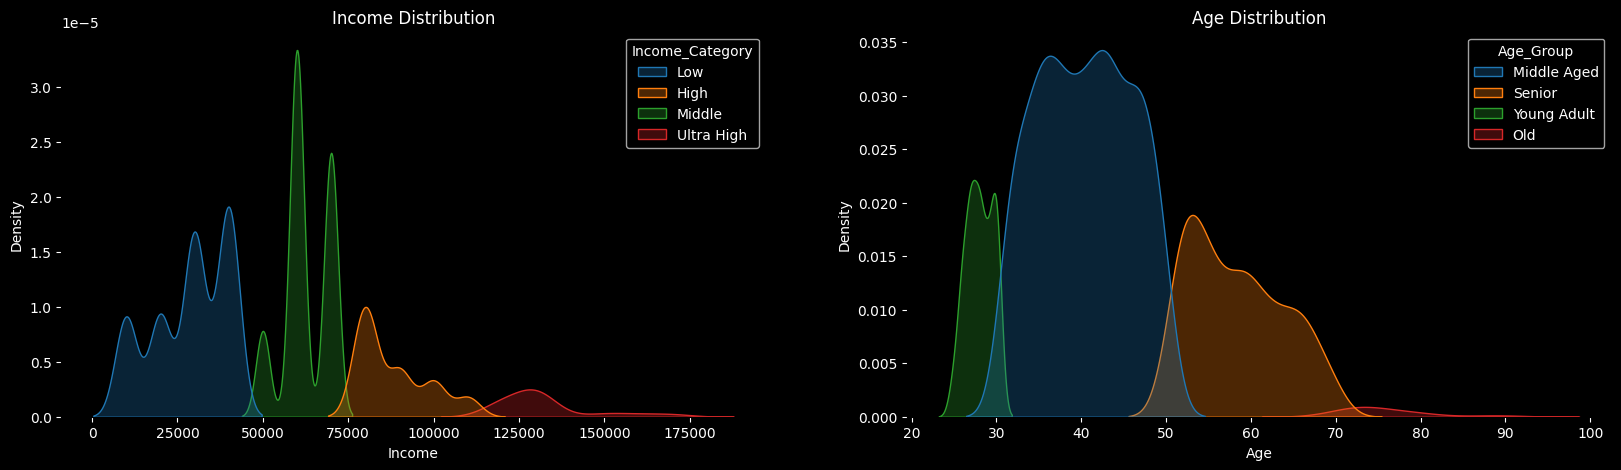

In [237]:
# Subplot untuk melihat density kolom income dan age berdasarkan kategori nya
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Kde plot 1: Income Category
sns.kdeplot(
    data = dfc, 
    x = "Income", 
    hue= "Income_Category", 
    fill=True, 
    alpha= 0.3,
    ax=axes[0]
    )
axes[0].set_title("Income Distribution")

# Kde plot 1: Income Category
sns.kdeplot(
    data = dfc, 
    x = "Age", 
    hue= "Age_Group", 
    fill=True, 
    alpha= 0.3,
    ax=axes[1]
    )
axes[1].set_title("Age Distribution")

plt.show()

Kerapatan/Density Data Income berdasarkan Income Category
- Variasi data terlebar terdapat pada Income Cetegory low
- Density tertinggi ada terdapat pada Income Category Middle pada rentan 60.000 - 70.000

Kerapatan/Density Data Age berdasarkan Age Group
- Variasi data terlebar terdapat pada Age Group Middle Aged
- Density tertinggi ada terdapat pada Age Group Middle Aged pada rentan 35 - 45 Tahun

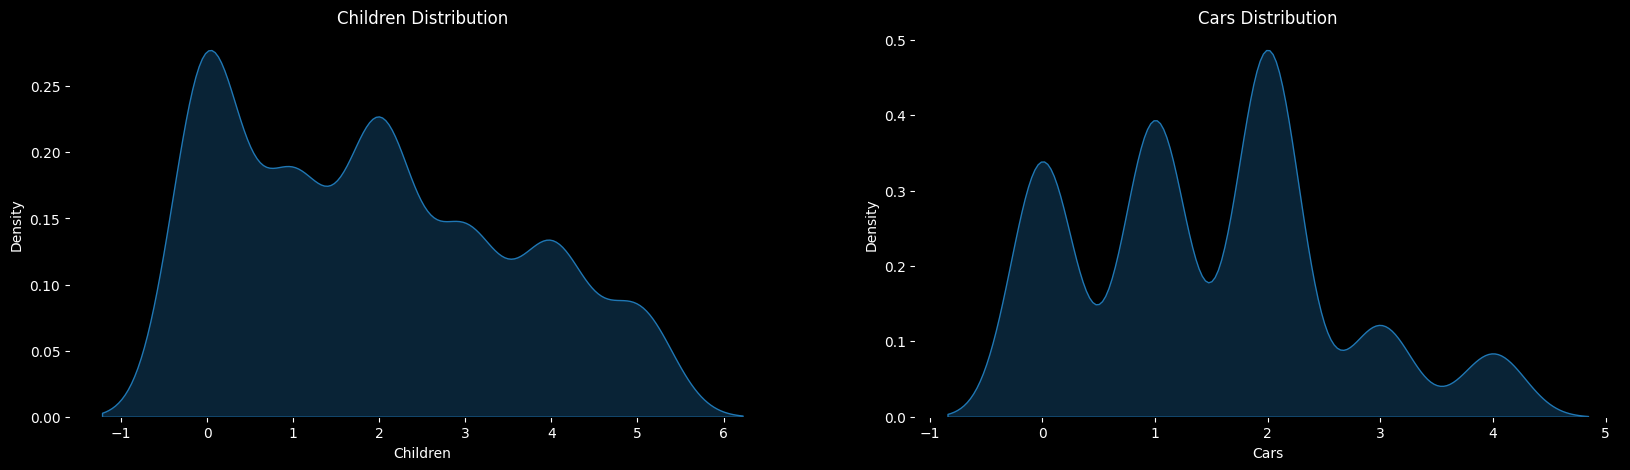

In [238]:
# Subplot untuk melihat density kolom Children dan Cars
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Kde plot 1: Children
sns.kdeplot(
    data = dfc, 
    x = "Children",
    fill=True, 
    alpha= 0.3,
    ax=axes[0]
    )
axes[0].set_title("Children Distribution")

# Kde plot 2: Cars
sns.kdeplot(
    data = dfc, 
    x = "Cars", 
    fill=True, 
    alpha= 0.3,
    ax=axes[1]
    )
axes[1].set_title("Cars Distribution")

plt.show()

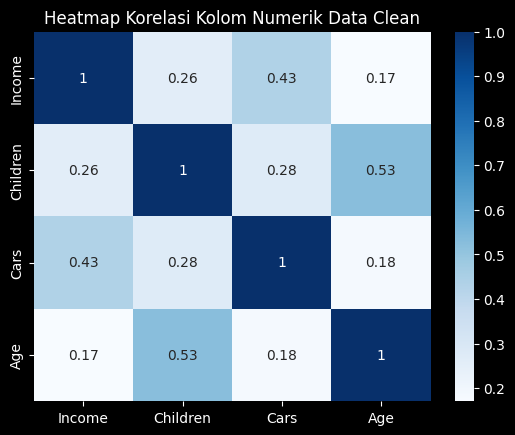

In [239]:
# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    dfc.select_dtypes(include='number').drop(columns='ID').corr(), 
    annot=True, 
    annot_kws={'size':10}, 
    cmap='Blues'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(rotation = 0)
plt.show()

Temuan pada Heatmap:
- Secara umum, tingkat hubungan cenderung tidak terlalu kuat
- Namun, masih terdapat hubungan antar kolom data
- Nilai hubungan terkuat pada heat map:\
-- Age & Children (0.53): Dapat diintrepretasikan dengan hubungan antara umur responden dengan jumlah anak yang dimiliki\
-- Cars & Income (0.43): Dapat diintrepretasikan dengan hubungan antara jumlah mobil yang dimiliki dengan pendapatan/gaji yang diterima oleh responden

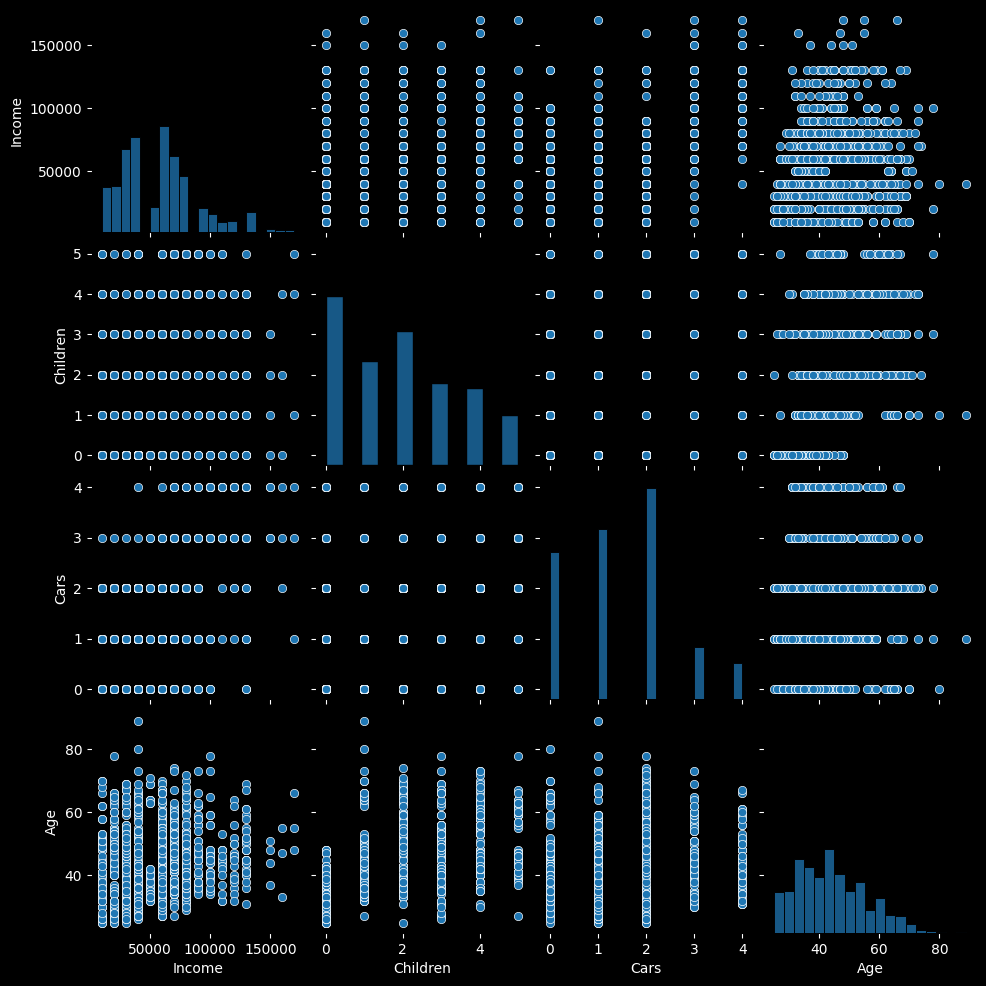

In [240]:
# Pair plot kolm numerik dataframe dfc
sns.pairplot(dfc.select_dtypes(include='number').drop(columns='ID'))
plt.show()

In [241]:
# Uji korelasi/hubungan kolom Age vs Children
corr, p_value = spearmanr(dfc['Age'], dfc['Children'])

print(f"Nilai corr/rho: {corr}")
print(f"Nilai P-Value: {p_value}")
print('\n')

if corr <= 0 and corr <= 0.19:
    print(f"Corr: {corr}, korelasi cenderung sangat lemah")

elif corr >= 0.20 and corr <= 0.39:
    print(f"Corr: {corr}, korelasi cenderung lemah")

elif corr >= 0.40 and corr <= 0.59:
    print(f"Corr: {corr}, korelasi cenderung sedang")

elif corr >= 0.60 and corr <= 0.79:
    print(f"Corr: {corr}, korelasi cenderung kuat")

else:
    print(f"Corr: {corr}, korelasi cenderung sangat kuat")

if p_value < 0.05:
    print(f"P-Value: {p_value} < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan")

else:
    print(f"P-Value: {p_value} >= 0.05, maka gagal Tolak H0: kemungkinan tidak memiliki hubungan")

Nilai corr/rho: 0.594939201269112
Nilai P-Value: 8.890241873179471e-97


Corr: 0.594939201269112, korelasi cenderung sangat kuat
P-Value: 8.890241873179471e-97 < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan


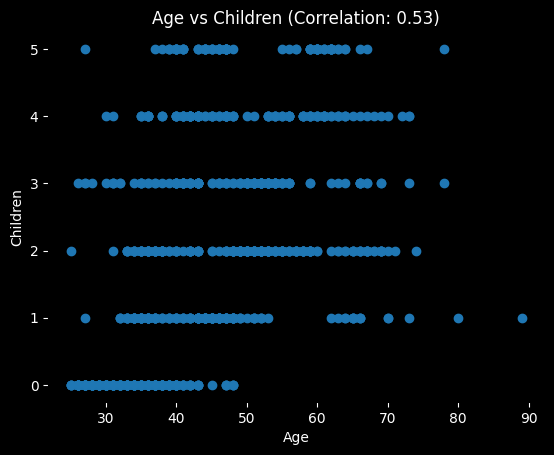

In [242]:
plt.scatter(
    data= dfc,
    x='Age',
    y='Children'
    )

plt.title('Age vs Children (Correlation: 0.53)')
plt.xlabel('Age')
plt.ylabel('Children')
plt.show()


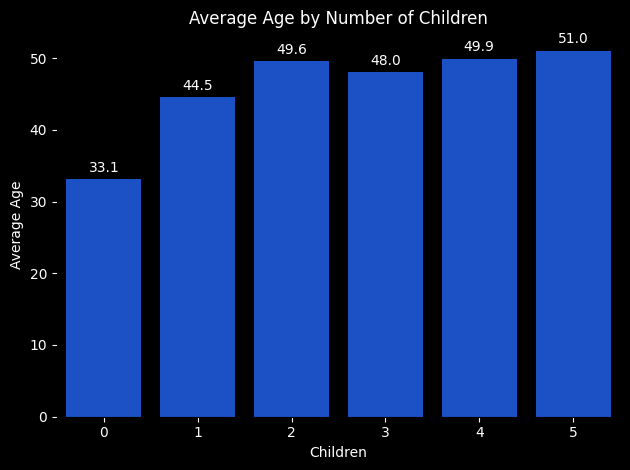

In [243]:
# Membuat bar chart kolom Children vs Age
ax = sns.barplot(
    data=dfc,
    x='Children',
    y='Age',
    errorbar=None,
    color= "#0045e1"
)

ax.bar_label(
    ax.containers[0], 
    fmt='%.1f', 
    padding=3)

plt.title("Average Age by Number of Children")
plt.ylabel("Average Age")
plt.tight_layout()
plt.show()

In [244]:
# Membuat Density Heatmap kolom Age vs Children
AgeChildPX = px.density_heatmap(
    dfc,
    x='Age',
    y='Children',
    nbinsx=15,
    nbinsy=5,
    title='Density: Age vs Children'
)

AgeChildPX.show()

In [245]:
# Uji korelasi/hubungan kolom Cars vs Income
corr, p_value = spearmanr(dfc['Cars'], dfc['Income'])

print(f"Nilai corr/rho: {corr}")
print(f"Nilai P-Value: {p_value}")
print('\n')

if corr <= 0 and corr <= 0.19:
    print(f"Corr: {corr}, korelasi cenderung sangat lemah")

elif corr >= 0.20 and corr <= 0.39:
    print(f"Corr: {corr}, korelasi cenderung lemah")

elif corr >= 0.40 and corr <= 0.59:
    print(f"Corr: {corr}, korelasi cenderung sedang")

elif corr >= 0.60 and corr <= 0.79:
    print(f"Corr: {corr}, korelasi cenderung kuat")

else:
    print(f"Corr: {corr}, korelasi cenderung sangat kuat")

if p_value < 0.05:
    print(f"P-Value: {p_value} < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan")

else:
    print(f"P-Value: {p_value} >= 0.05, maka gagal Tolak H0: kemungkinan tidak memiliki hubungan")

Nilai corr/rho: 0.32771135032854193
Nilai P-Value: 1.8293672908724098e-26


Corr: 0.32771135032854193, korelasi cenderung lemah
P-Value: 1.8293672908724098e-26 < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan


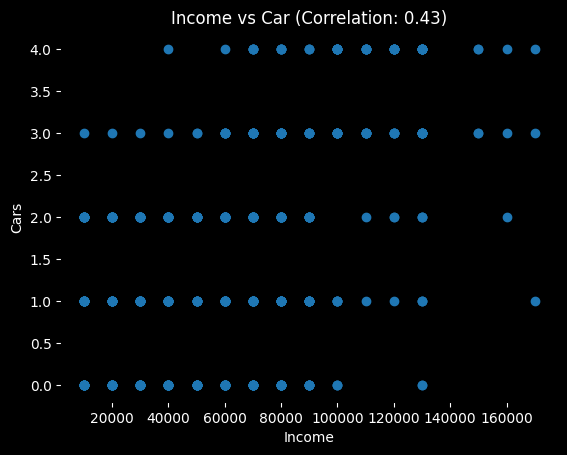

In [246]:
plt.scatter(
    data= dfc,
    x='Income',
    y='Cars'
    )

plt.title('Income vs Car (Correlation: 0.43)')
plt.xlabel('Income')
plt.ylabel('Cars')

plt.show()

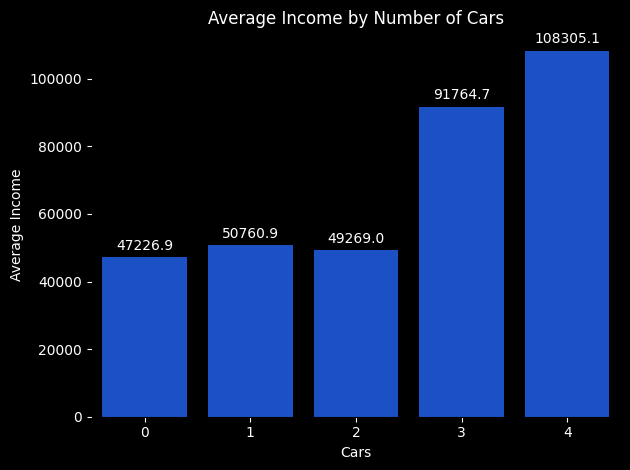

In [247]:
ax = sns.barplot(
    data=dfc,
    x='Cars',
    y='Income',
    errorbar=None,
    color= "#0045e1"
)

ax.bar_label(
    ax.containers[0], 
    fmt='%.1f', 
    padding=3
    )
plt.title("Average Income by Number of Cars")
plt.ylabel("Average Income")
plt.tight_layout()
plt.show()

In [248]:
# Membuat Density Heatmap kolom Income vs Cars
CarsIncomePX = px.density_heatmap(
    dfc,
    x='Income',
    y='Cars',
    nbinsx=15,
    nbinsy=5,
    title='Density: Income vs Cars'
)

CarsIncomePX.show()

## 7. Transformasi Data

In [249]:
# Variable untuk kolom denngan transformasi data
dft = dfc.copy() # dft (Data Frame Transformasi)
dft.head()

,ID,Marital_Status,Gender,Income,Income_Category,Children,Having_Children,Education,Occupation,Home_Owner,Cars,Car_Owner,Commute_Distance,Region,Age,Age_Group,Purchased_Bike
0,12496,Married,Female,40000.0,Low,1,Yes,Bachelors,Skilled Manual,Yes,0,No,0-1 Miles,Europe,42,Middle Aged,No
1,24107,Married,Male,30000.0,Low,3,Yes,Partial College,Clerical,Yes,1,Yes,0-1 Miles,Europe,43,Middle Aged,No
2,14177,Married,Male,80000.0,High,5,Yes,Partial College,Professional,No,2,Yes,2-5 Miles,Europe,60,Senior,No
3,24381,Single,Unknown,70000.0,Middle,0,No,Bachelors,Professional,Yes,1,Yes,5-10 Miles,Pacific,41,Middle Aged,Yes
4,25597,Single,Male,30000.0,Low,0,No,Bachelors,Clerical,No,0,No,0-1 Miles,Europe,36,Middle Aged,Yes


In [250]:
# Membuat kolom dengan nilai encoding untuk kolom kategorikal object
le= LabelEncoder()
dft['Encode_PB'] = le.fit_transform(dft['Purchased_Bike'])
dft['Encode_MS'] = le.fit_transform(dft['Marital_Status'])
dft['Encode_Gen'] = le.fit_transform(dft['Gender'])
dft['Encode_Oc'] = le.fit_transform(dft['Occupation'])
dft['Encode_HO'] = le.fit_transform(dft['Home_Owner'])
dft['Encode_Re'] = le.fit_transform(dft['Region'])

In [251]:
dft["Commute_Distance"].unique()

array(['0-1 Miles', '2-5 Miles', '5-10 Miles', '1-2 Miles', '10+ Miles'],
      dtype=object)

In [252]:
# Encoder Commute Distance dan membuat kolom baru "Commute_Distance_Encode"
encoder_CD = OrdinalEncoder(categories= [["0-1 Miles", "1-2 Miles", "2-5 Miles", "5-10 Miles", "10+ Miles"]])
dft["Encode_CD"] = encoder_CD.fit_transform(dft[["Commute_Distance"]])

In [253]:
dft["Education"].unique()

array(['Bachelors', 'Partial College', 'High School',
       'Partial High School', 'Graduate Degree'], dtype=object)

In [254]:
# Encoder Education dan membuat kolom baru "encoder_education"
encoder_Ed = OrdinalEncoder(categories= [["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]])
dft["Encode_Ed"] = encoder_Ed.fit_transform(dfc[["Education"]])

In [255]:
dft.head()

,ID,Marital_Status,Gender,Income,Income_Category,Children,Having_Children,Education,Occupation,Home_Owner,Cars,Car_Owner,Commute_Distance,Region,Age,Age_Group,Purchased_Bike,Encode_PB,Encode_MS,Encode_Gen,Encode_Oc,Encode_HO,Encode_Re,Encode_CD,Encode_Ed
0,12496,Married,Female,40000.0,Low,1,Yes,Bachelors,Skilled Manual,Yes,0,No,0-1 Miles,Europe,42,Middle Aged,No,0,0,0,4,1,0,0.0,3.0
1,24107,Married,Male,30000.0,Low,3,Yes,Partial College,Clerical,Yes,1,Yes,0-1 Miles,Europe,43,Middle Aged,No,0,0,1,0,1,0,0.0,2.0
2,14177,Married,Male,80000.0,High,5,Yes,Partial College,Professional,No,2,Yes,2-5 Miles,Europe,60,Senior,No,0,0,1,3,0,0,2.0,2.0
3,24381,Single,Unknown,70000.0,Middle,0,No,Bachelors,Professional,Yes,1,Yes,5-10 Miles,Pacific,41,Middle Aged,Yes,1,1,2,3,1,2,3.0,3.0
4,25597,Single,Male,30000.0,Low,0,No,Bachelors,Clerical,No,0,No,0-1 Miles,Europe,36,Middle Aged,Yes,1,1,1,0,0,0,0.0,3.0


In [256]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital_Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Income_Category   1000 non-null   object 
 5   Children          1000 non-null   int64  
 6   Having_Children   1000 non-null   object 
 7   Education         1000 non-null   object 
 8   Occupation        1000 non-null   object 
 9   Home_Owner        1000 non-null   object 
 10  Cars              1000 non-null   int64  
 11  Car_Owner         1000 non-null   object 
 12  Commute_Distance  1000 non-null   object 
 13  Region            1000 non-null   object 
 14  Age               1000 non-null   int64  
 15  Age_Group         1000 non-null   object 
 16  Purchased_Bike    1000 non-null   object 
 

In [257]:
dft.columns

Index(['ID', 'Marital_Status', 'Gender', 'Income', 'Income_Category',
       'Children', 'Having_Children', 'Education', 'Occupation', 'Home_Owner',
       'Cars', 'Car_Owner', 'Commute_Distance', 'Region', 'Age', 'Age_Group',
       'Purchased_Bike', 'Encode_PB', 'Encode_MS', 'Encode_Gen', 'Encode_Oc',
       'Encode_HO', 'Encode_Re', 'Encode_CD', 'Encode_Ed'],
      dtype='object')

In [258]:
dft = dft[['ID', 'Marital_Status', 'Encode_MS', 'Gender', 'Encode_Gen', 
           'Income', 'Income_Category', 'Children', 'Education', 'Encode_Ed',
           'Occupation', 'Encode_Oc', 'Home_Owner', 'Encode_HO', 'Cars', 'Commute_Distance', 'Encode_CD', 
           'Region', 'Encode_Re', 'Age', 'Age_Group', 'Purchased_Bike', 'Encode_PB']]

In [259]:
pd.set_option('display.max_columns', None)

In [260]:
dft.head()

,ID,Marital_Status,Encode_MS,Gender,Encode_Gen,Income,Income_Category,Children,Education,Encode_Ed,Occupation,Encode_Oc,Home_Owner,Encode_HO,Cars,Commute_Distance,Encode_CD,Region,Encode_Re,Age,Age_Group,Purchased_Bike,Encode_PB
0,12496,Married,0,Female,0,40000.0,Low,1,Bachelors,3.0,Skilled Manual,4,Yes,1,0,0-1 Miles,0.0,Europe,0,42,Middle Aged,No,0
1,24107,Married,0,Male,1,30000.0,Low,3,Partial College,2.0,Clerical,0,Yes,1,1,0-1 Miles,0.0,Europe,0,43,Middle Aged,No,0
2,14177,Married,0,Male,1,80000.0,High,5,Partial College,2.0,Professional,3,No,0,2,2-5 Miles,2.0,Europe,0,60,Senior,No,0
3,24381,Single,1,Unknown,2,70000.0,Middle,0,Bachelors,3.0,Professional,3,Yes,1,1,5-10 Miles,3.0,Pacific,2,41,Middle Aged,Yes,1
4,25597,Single,1,Male,1,30000.0,Low,0,Bachelors,3.0,Clerical,0,No,0,0,0-1 Miles,0.0,Europe,0,36,Middle Aged,Yes,1


In [261]:
# Variable untuk mengambil dataframe numerik dari dft
dft_num = dft.iloc[:,1:].select_dtypes(include='number')

In [262]:
dft_num

,Encode_MS,Encode_Gen,Income,Children,Encode_Ed,Encode_Oc,Encode_HO,Cars,Encode_CD,Encode_Re,Age,Encode_PB
0,0,0,40000.0,1,3.0,4,1,0,0.0,0,42,0
1,0,1,30000.0,3,2.0,0,1,1,0.0,0,43,0
2,0,1,80000.0,5,2.0,3,0,2,2.0,0,60,0
3,1,2,70000.0,0,3.0,3,1,1,3.0,2,41,1
4,1,1,30000.0,0,3.0,0,0,0,0.0,0,36,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,60000.0,2,1.0,3,1,2,2.0,1,54,1
996,1,1,70000.0,4,4.0,3,1,0,2.0,1,35,1
997,0,2,60000.0,2,3.0,4,1,0,0.0,1,38,1
998,1,1,100000.0,3,3.0,1,0,3,1.0,1,38,0


In [263]:
uji_shapiro = []

for col in dft_num:
    skewness = dft_num[col].skew()
    stat, p_value = shapiro(dft[col])

    if p_value > 0.05:
        kesimpulan = "Normal"
    else:
        kesimpulan = "Tidak Normal"

    uji_shapiro.append({
        "Kolom": col,
        "Skewness": skewness,
        "Statistic": stat,
        "P-Value": p_value,
        "Kesimpulan": kesimpulan
    })

df_uji_shapiro = pd.DataFrame(uji_shapiro)
df_uji_shapiro

,Kolom,Skewness,Statistic,P-Value,Kesimpulan
0,Encode_MS,0.156712,0.634375,1.121998e-41,Tidak Normal
1,Encode_Gen,0.145606,0.673930,5.020699e-40,Tidak Normal
2,Income,0.751168,0.944142,5.688197e-19,Tidak Normal
3,Children,0.393232,0.892520,8.013958e-26,Tidak Normal
4,Encode_Ed,-0.284322,0.907397,3.653705e-24,Tidak Normal
5,Encode_Oc,-0.303832,0.862256,1.026786e-28,Tidak Normal
6,Encode_HO,-0.797725,0.584786,1.497995e-43,Tidak Normal
7,Cars,0.429246,0.887892,2.653775e-26,Tidak Normal
8,Encode_CD,0.368967,0.847276,5.754838e-30,Tidak Normal
9,Encode_Re,0.147076,0.802242,3.190279e-33,Tidak Normal


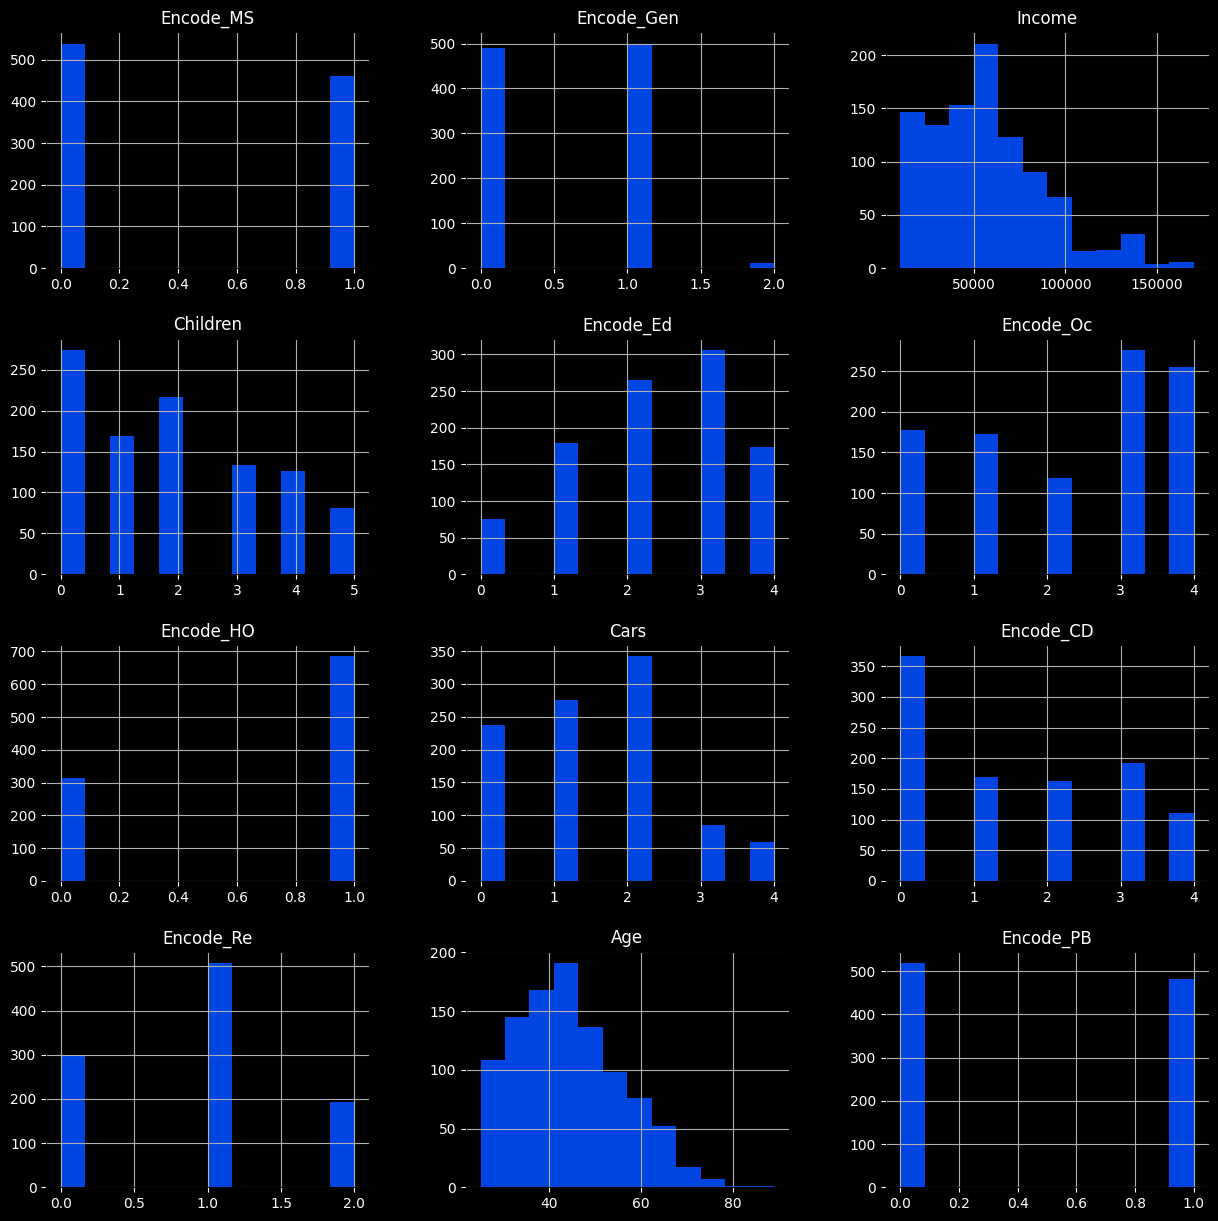

In [264]:
# Membuat histogram untuk semua dft_num (melihat bentuk distribusi data)
dft_num.hist(
    bins=12, #skala figure
    figsize=(15,15), #ukuran figure
    color= "#0045e1", #warna chart
)
plt.show()

- Secara garis besar, seluruh kolom cenderung memiliki distribusi tidak normal

## 8. Data Exploration (Dataset dengan Encoding)

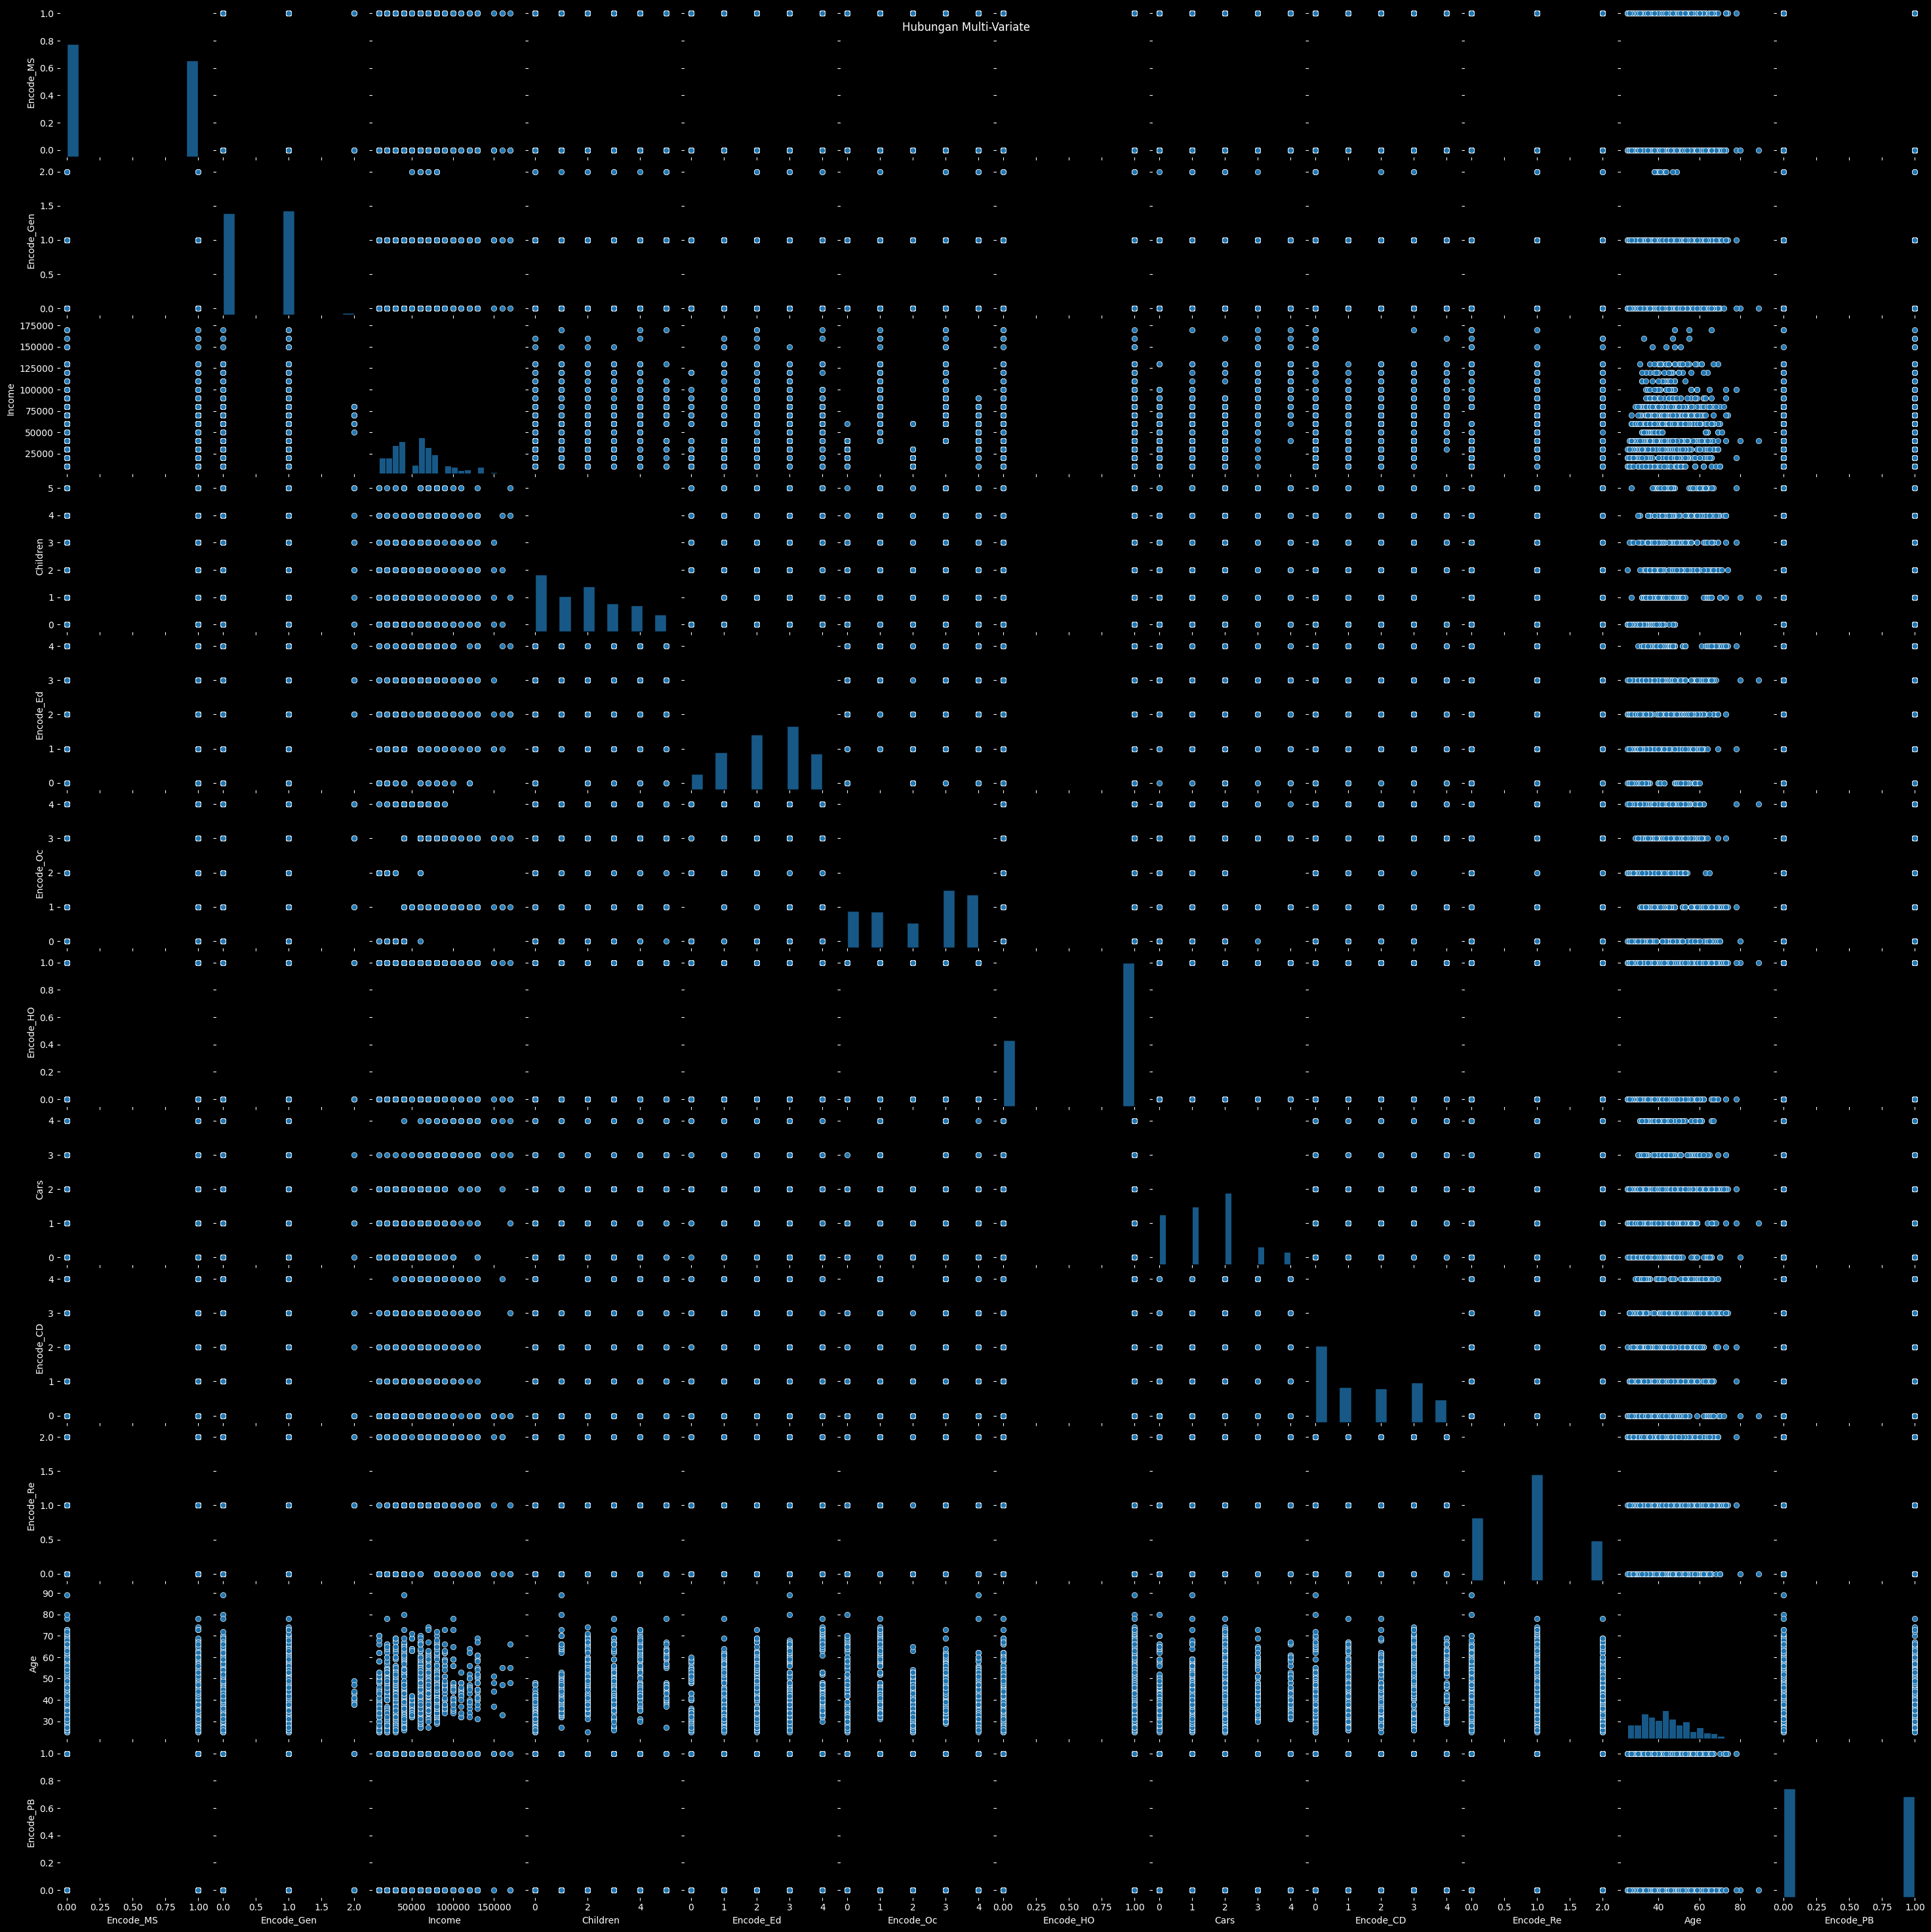

In [265]:
# Membuat pairplot dft_num
sns.pairplot(dft_num)
plt.suptitle('Hubungan Multi-Variate')
plt.show()

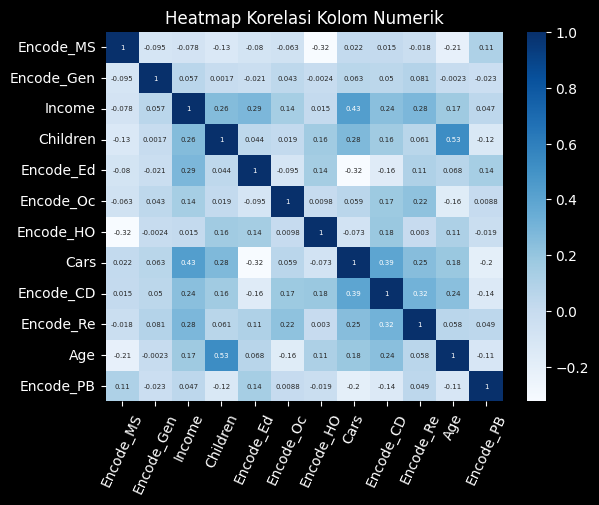

In [266]:
# Membuat heatmap dft_num
sns.heatmap(
    dft_num.corr(), 
    annot=True, 
    annot_kws={'size':5}, 
    cmap='Blues'
    )
plt.title('Heatmap Korelasi Kolom Numerik')
plt.xticks(rotation = 65)
plt.show()

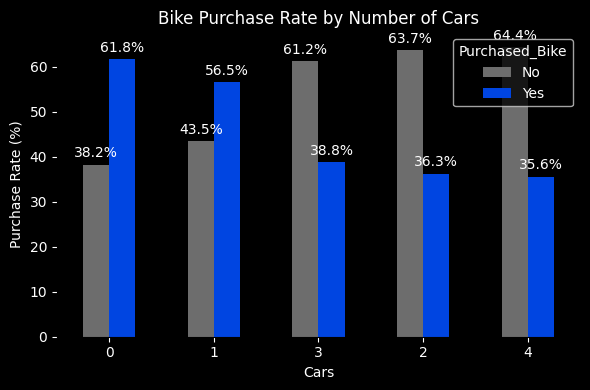

In [267]:
# buat crosstab kolom cars vs purchased_bike
CT_CarsPB = (pd.crosstab(
    dft['Cars'],
    dft['Purchased_Bike'],
    normalize='index'
) * 100).round(2)


ax = CT_CarsPB.sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color= ["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )
plt.ylabel("Purchase Rate (%)")
plt.title("Bike Purchase Rate by Number of Cars")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

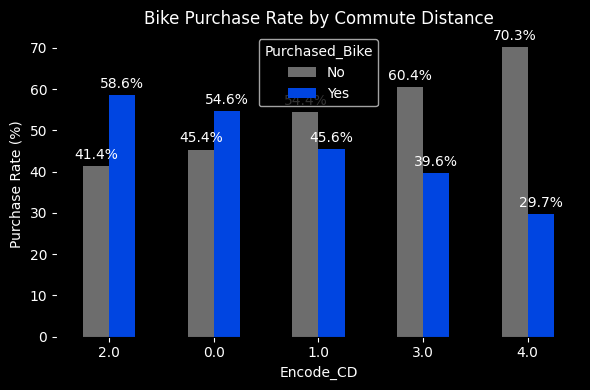

In [268]:
# buat crosstab dulu (persentase)
CT_CommutePB = (pd.crosstab(
    dft['Encode_CD'],
    dft['Purchased_Bike'],
    normalize='index'
) * 100).round(2)


# plot (ambil hanya Yes untuk conversion rate)
ax = CT_CommutePB.sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color= ["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Purchase Rate (%)")
plt.title("Bike Purchase Rate by Commute Distance")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [269]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital_Status    1000 non-null   object 
 2   Encode_MS         1000 non-null   int64  
 3   Gender            1000 non-null   object 
 4   Encode_Gen        1000 non-null   int64  
 5   Income            1000 non-null   float64
 6   Income_Category   1000 non-null   object 
 7   Children          1000 non-null   int64  
 8   Education         1000 non-null   object 
 9   Encode_Ed         1000 non-null   float64
 10  Occupation        1000 non-null   object 
 11  Encode_Oc         1000 non-null   int64  
 12  Home_Owner        1000 non-null   object 
 13  Encode_HO         1000 non-null   int64  
 14  Cars              1000 non-null   int64  
 15  Commute_Distance  1000 non-null   object 
 16  Encode_CD         1000 non-null   float64
 

## Analisa Survey Bike Buyers (Data Clean)

In [270]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital_Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Income_Category   1000 non-null   object 
 5   Children          1000 non-null   int64  
 6   Having_Children   1000 non-null   object 
 7   Education         1000 non-null   object 
 8   Occupation        1000 non-null   object 
 9   Home_Owner        1000 non-null   object 
 10  Cars              1000 non-null   int64  
 11  Car_Owner         1000 non-null   object 
 12  Commute_Distance  1000 non-null   object 
 13  Region            1000 non-null   object 
 14  Age               1000 non-null   int64  
 15  Age_Group         1000 non-null   object 
 16  Purchased_Bike    1000 non-null   object 
d

In [271]:
# Grouping pemebli sepeda
PurchasedBikeProp = dfc.groupby('Purchased_Bike').agg(
    Jumlah_Responden = ('ID', 'count')
).reset_index()

PurchasedBikeProp['Pesentase(%)'] = round((PurchasedBikeProp['Jumlah_Responden']/len(dfc)*100),2)

In [272]:
PurchasedBikeProp

,Purchased_Bike,Jumlah_Responden,Pesentase(%)
0,No,519,51.9
1,Yes,481,48.1


Text(0.5, 1.0, 'Proporsi Pembeli Sepeda (Yes/No)')

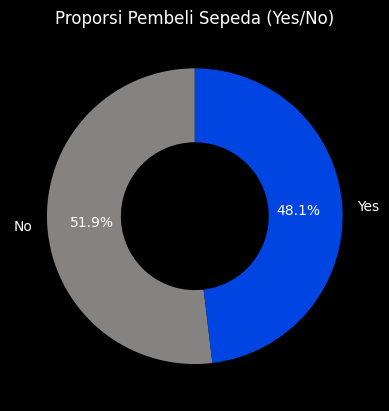

In [273]:
# Membuat pie chart populasi pemebli sepeda
PurchasedBikeProp = df['Purchased Bike'].value_counts()

plt.pie(
    PurchasedBikeProp,
    labels= PurchasedBikeProp.index,
    autopct= "%1.1f%%",
    wedgeprops=dict(width= 0.5),
    pctdistance=0.7,
    startangle= 90,
    colors= ["#858282", '#0045e1']
    )
plt.title('Proporsi Pembeli Sepeda (Yes/No)')

In [274]:
# Mengambil nama kolom object, kecuali Purchased_Bike
dfc_cat = dfc.select_dtypes(include='O').columns[:11]

dfc_cat

Index(['Marital_Status', 'Gender', 'Income_Category', 'Having_Children',
       'Education', 'Occupation', 'Home_Owner', 'Car_Owner',
       'Commute_Distance', 'Region', 'Age_Group'],
      dtype='object')

In [275]:
# Menampilkan proporsi pembali sepeda untuk semua kolom object
for col in dfc_cat:

    CT_Cat = (pd.crosstab(
        dfc[col],
        dfc['Purchased_Bike'],
        margins=True,
        margins_name='Total',
        normalize='index'
    )*100).round(2)
    print(f'===CrossTab Percentage Purchased_Bike by {col}===')
    print(CT_Cat)
    print('\n')

===CrossTab Percentage Purchased_Bike by Marital_Status===
Purchased_Bike     No    Yes
Marital_Status              
Married         56.96  43.04
Single          45.99  54.01
Total           51.90  48.10


===CrossTab Percentage Purchased_Bike by Gender===
Purchased_Bike     No    Yes
Gender                      
Female          51.12  48.88
Male            52.20  47.80
Unknown         72.73  27.27
Total           51.90  48.10


===CrossTab Percentage Purchased_Bike by Income_Category===
Purchased_Bike      No    Yes
Income_Category              
High             55.49  44.51
Low              53.69  46.31
Middle           48.50  51.50
Ultra High       47.46  52.54
Total            51.90  48.10


===CrossTab Percentage Purchased_Bike by Having_Children===
Purchased_Bike      No    Yes
Having_Children              
No               49.27  50.73
Yes              52.89  47.11
Total            51.90  48.10


===CrossTab Percentage Purchased_Bike by Education===
Purchased_Bike          No   

Dari survey, terdapat beberapa temuan proporsi tiap kategori yang memiliki sepeda dan cukup dominan:

- Responden punya sepeda: 48.10%
- Komposisi Income_Category Low: 46.31%
- Komposisi Income_Category Ultra_High: 52.54%
- Komposisi Income_Category Middle: 51.50%
- Komposisi Education Bachelors: 55.23%
- Komposisi Education Graduate Degree: 54.02%
- Komposisi Occupation Professional: 54.35
- Komposisi Tidak punya mobil: 61.76%
- komposisi Commute_Distance 2-5 Miles: 58.64
- Komposisi Region Pacific: 58.85% 
- komposisi Age_Group Middle-Aged: 54.05

In [276]:

CT_CarOwnersPB = pd.crosstab(
    dfc['Car_Owner'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_CarOwnersPB

Purchased_Bike,No,Yes,Total
Car_Owner,,,
No,91,147,238
Yes,428,334,762
Total,519,481,1000


In [277]:

CT_CarOwnersPB_Percent = (pd.crosstab(
    dfc['Car_Owner'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_CarOwnersPB_Percent

Purchased_Bike,No,Yes
Car_Owner,,
No,38.24,61.76
Yes,56.17,43.83
Total,51.90,48.10


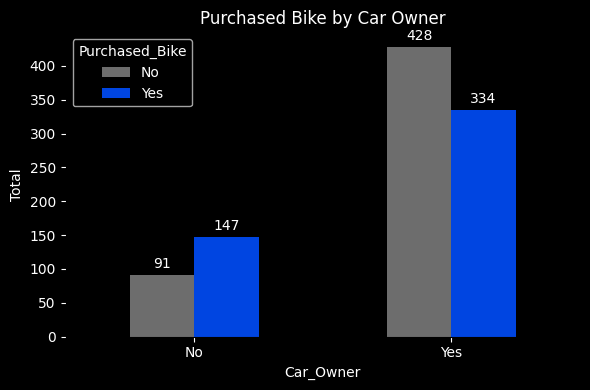

In [278]:

ax = CT_CarOwnersPB.drop(index='Total', columns='Total').sort_values(by='No', ascending=True).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )
plt.ylabel("Total")
plt.title("Purchased Bike by Car Owner")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

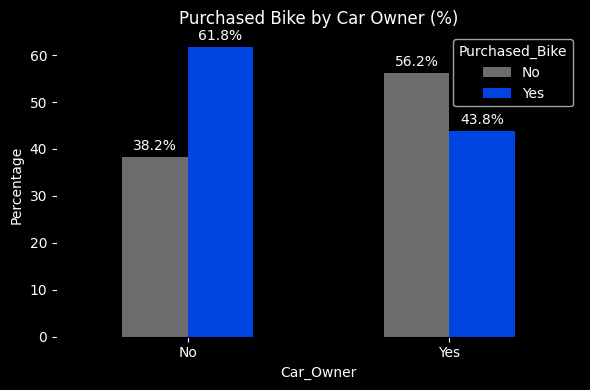

In [279]:
ax = CT_CarOwnersPB_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Car Owner (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [280]:
CT_CommuteDistancePB = pd.crosstab(
    dfc['Commute_Distance'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_CommuteDistancePB

Purchased_Bike,No,Yes,Total
Commute_Distance,,,
0-1 Miles,166,200,366
1-2 Miles,92,77,169
10+ Miles,78,33,111
2-5 Miles,67,95,162
5-10 Miles,116,76,192
Total,519,481,1000


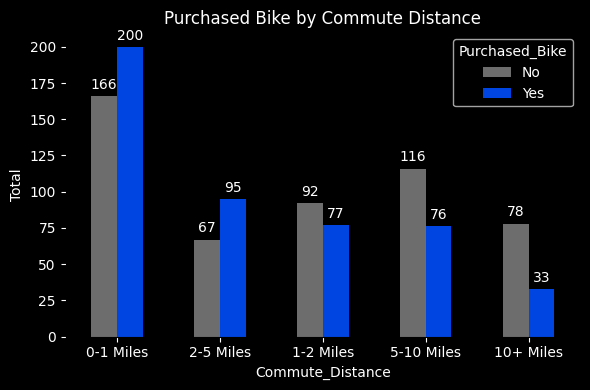

In [281]:
ax = CT_CommuteDistancePB.drop(index='Total', columns='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total")
plt.title("Purchased Bike by Commute Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [282]:
CT_CommuteDistancePB_Percent = (pd.crosstab(
    dfc['Commute_Distance'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_CommuteDistancePB_Percent

Purchased_Bike,No,Yes
Commute_Distance,,
0-1 Miles,45.36,54.64
1-2 Miles,54.44,45.56
10+ Miles,70.27,29.73
2-5 Miles,41.36,58.64
5-10 Miles,60.42,39.58
Total,51.90,48.10


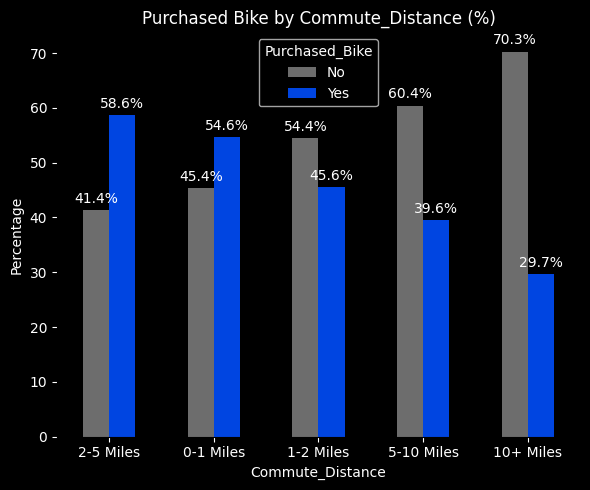

In [283]:
ax = CT_CommuteDistancePB_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,5),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Commute_Distance (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [284]:
Group_CommuteDistancePB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Commute_Distance')
    .size()
    .reset_index(name='Total_Buyers')
)

Group_CommuteDistancePB

,Commute_Distance,Total_Buyers
0,0-1 Miles,200
1,1-2 Miles,77
2,10+ Miles,33
3,2-5 Miles,95
4,5-10 Miles,76


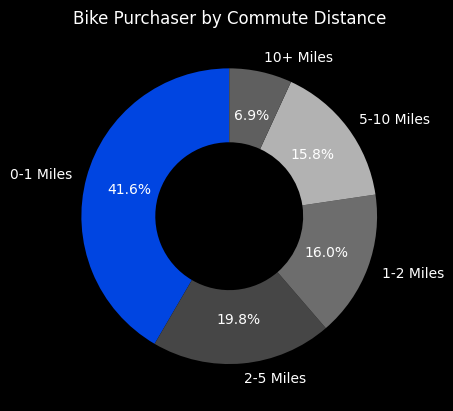

In [285]:
Pie_CommuteDistancePB = dfc[dfc['Purchased_Bike'] == 'Yes']["Commute_Distance"].value_counts()
plt.pie(
    Pie_CommuteDistancePB,
    labels= Pie_CommuteDistancePB.index,
    autopct= "%1.1f%%",
    pctdistance=0.7,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Commute Distance')
plt.show()

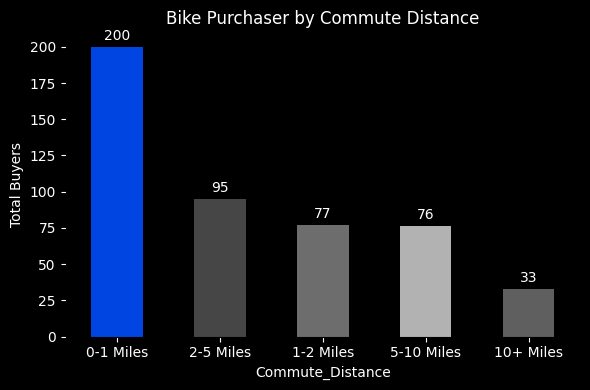

In [286]:
ax = Pie_CommuteDistancePB.drop(columns='Total').plot(
    kind='bar',
    figsize=(6,4),
    color=[ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total Buyers")
plt.title("Bike Purchaser by Commute Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [287]:
CT_IncomeCategoryPB = pd.crosstab(
    dfc['Income_Category'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_IncomeCategoryPB

Purchased_Bike,No,Yes,Total
Income_Category,,,
High,96,77,173
Low,233,201,434
Middle,162,172,334
Ultra High,28,31,59
Total,519,481,1000


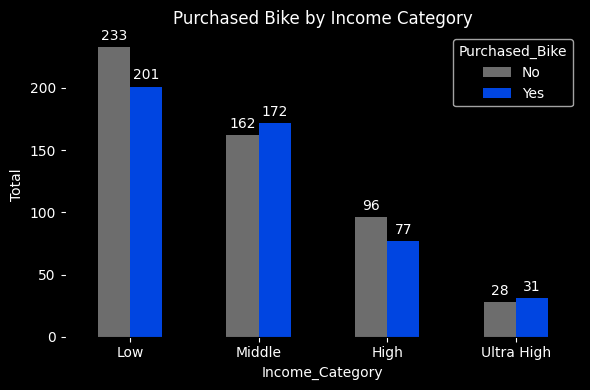

In [288]:
ax = CT_IncomeCategoryPB.drop(index='Total', columns='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total")
plt.title("Purchased Bike by Income Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [289]:
CT_IncomeCategory_Percent = (pd.crosstab(
    dfc['Income_Category'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_IncomeCategory_Percent

Purchased_Bike,No,Yes
Income_Category,,
High,55.49,44.51
Low,53.69,46.31
Middle,48.50,51.50
Ultra High,47.46,52.54
Total,51.90,48.10


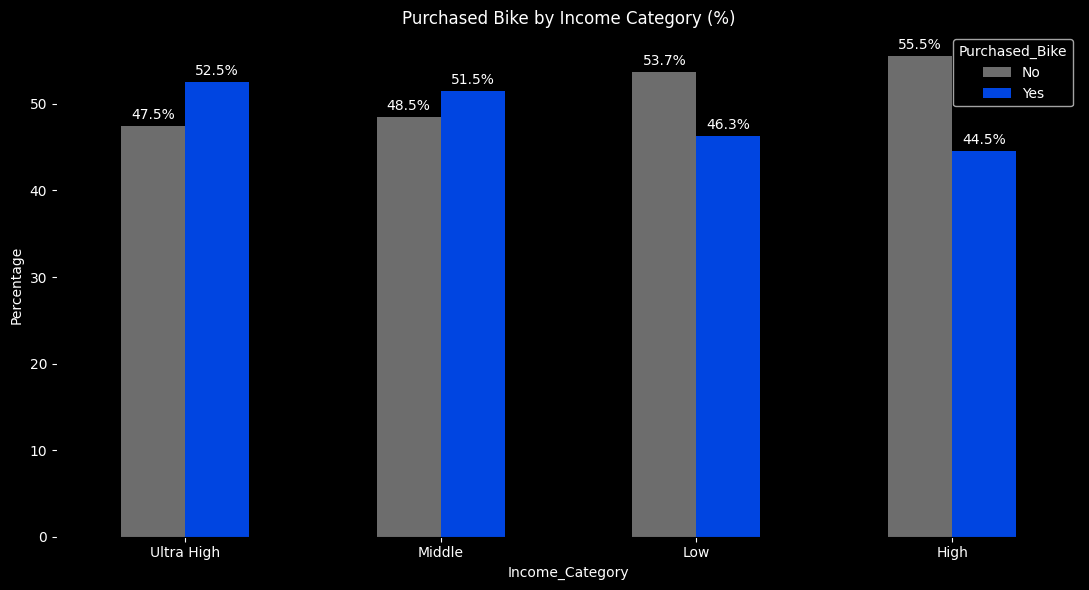

In [290]:
ax = CT_IncomeCategory_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(11,6),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Income Category (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [291]:
Group_IncomeCategoryPB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Income_Category')
    .size()
    .reset_index(name='Total_Buyers')
)

Group_IncomeCategoryPB

,Income_Category,Total_Buyers
0,High,77
1,Low,201
2,Middle,172
3,Ultra High,31


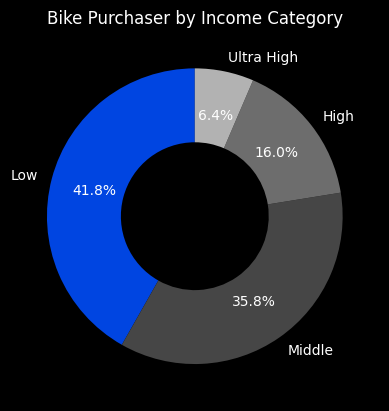

In [292]:
Pie_IncomeCategoryPB = dfc[dfc['Purchased_Bike'] == 'Yes']["Income_Category"].value_counts()
plt.pie(
    Pie_IncomeCategoryPB,
    labels= Pie_IncomeCategoryPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.7,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Income Category')
plt.show()

In [293]:
CT_EducationPB = pd.crosstab(
    dfc['Education'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_EducationPB.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes,Total
Education,,,
Total,519,481,1000
Bachelors,137,169,306
Partial College,146,119,265
Graduate Degree,80,94,174
High School,100,79,179
Partial High School,56,20,76


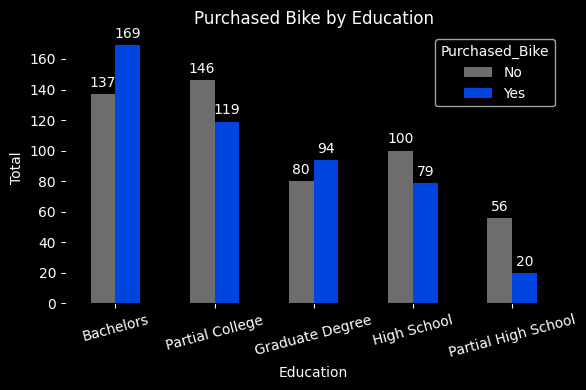

In [294]:
ax = CT_EducationPB.drop(index='Total', columns='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total")
plt.title("Purchased Bike by Education")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [295]:
CT_Education_Percent = (pd.crosstab(
    dfc['Education'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_Education_Percent.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes
Education,,
Bachelors,44.77,55.23
Graduate Degree,45.98,54.02
Total,51.90,48.10
Partial College,55.09,44.91
High School,55.87,44.13
Partial High School,73.68,26.32


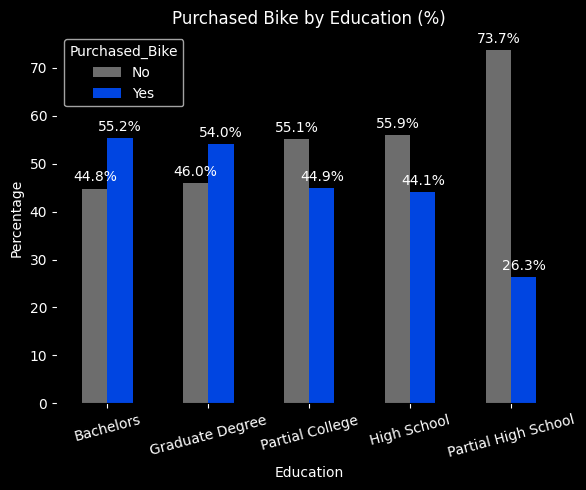

In [296]:
ax = CT_Education_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,5),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Education (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [297]:
Group_EducationPB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Education')
    .size()
    .reset_index(name='Total_Buyers')
    .sort_values(by='Total_Buyers', ascending=False)
)

Group_EducationPB.sort_values(by='Total_Buyers', ascending=False)

,Education,Total_Buyers
0,Bachelors,169
3,Partial College,119
1,Graduate Degree,94
2,High School,79
4,Partial High School,20


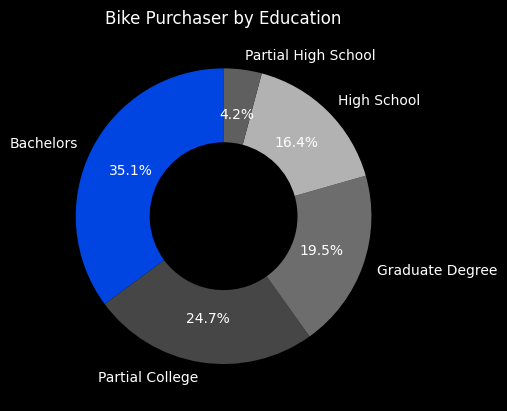

In [298]:
Pie_EducationPB = dfc[dfc['Purchased_Bike'] == 'Yes']["Education"].value_counts()
plt.pie(
    Pie_EducationPB,
    labels= Pie_EducationPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.7,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Education')
plt.show()

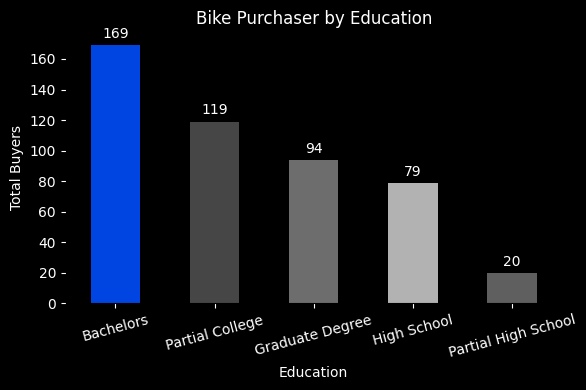

In [299]:
ax = Pie_EducationPB.drop(columns='Total').plot(
    kind='bar',
    figsize=(6,4),
    color=[ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )
plt.ylabel("Total Buyers")
plt.title("Bike Purchaser by Education")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [300]:
CT_AgeGroupPB = pd.crosstab(
    dfc['Age_Group'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_AgeGroupPB.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes,Total
Age_Group,,,
Total,519,481,1000
Middle Aged,284,334,618
Senior,159,104,263
Young Adult,70,38,108
Old,6,5,11


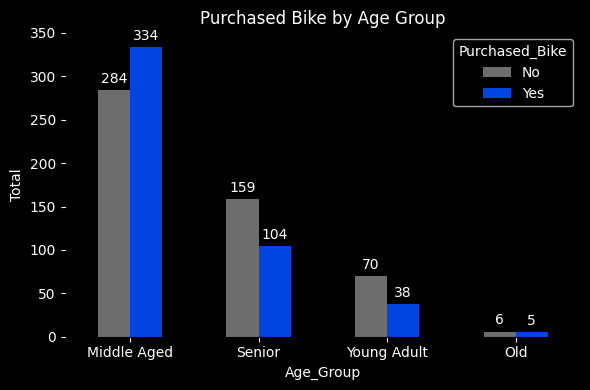

In [301]:
ax = CT_AgeGroupPB.drop(index='Total', columns='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total")
plt.title("Purchased Bike by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [302]:
CT_AgeGroup_Percent = (pd.crosstab(
    dfc['Age_Group'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_AgeGroup_Percent.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes
Age_Group,,
Middle Aged,45.95,54.05
Total,51.90,48.10
Old,54.55,45.45
Senior,60.46,39.54
Young Adult,64.81,35.19


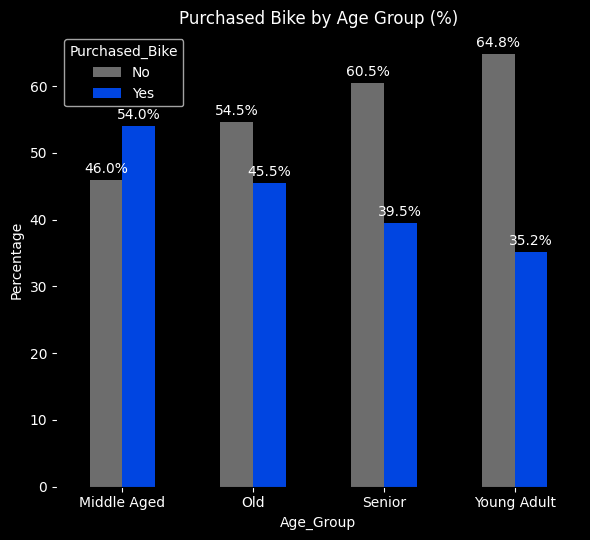

In [303]:
ax = CT_AgeGroup_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,5.5),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Age Group (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [304]:
Group_AgeGroupPB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Age_Group')
    .size()
    .reset_index(name='Total_Buyers')
    .sort_values(by='Total_Buyers', ascending=False)
)

Group_AgeGroupPB.sort_values(by='Total_Buyers', ascending=False)

,Age_Group,Total_Buyers
0,Middle Aged,334
2,Senior,104
3,Young Adult,38
1,Old,5


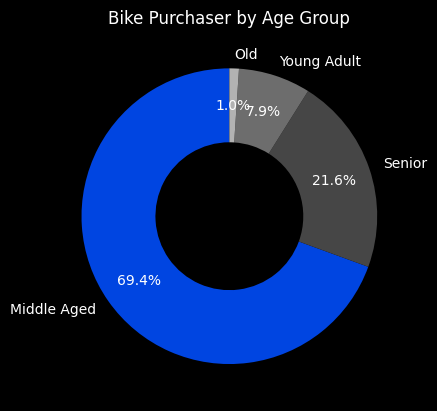

In [305]:
Pie_AgeGroupPB = dfc[dfc['Purchased_Bike'] == 'Yes']["Age_Group"].value_counts()
plt.pie(
    Pie_AgeGroupPB,
    labels= Pie_AgeGroupPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.75,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Age Group')
plt.show()

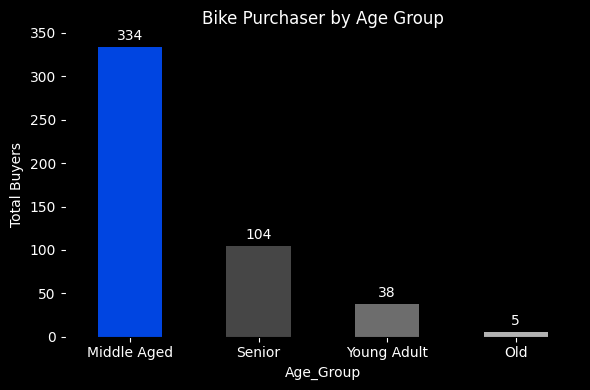

In [306]:
ax = Pie_AgeGroupPB.drop(columns='Total').plot(
    kind='bar',
    figsize=(6,4),
    color=[ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total Buyers")
plt.title("Bike Purchaser by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [307]:
CT_OccupationPB = pd.crosstab(
    dfc['Occupation'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total'
    )

CT_OccupationPB.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes,Total
Occupation,,,
Total,519,481,1000
Professional,126,150,276
Skilled Manual,140,115,255
Clerical,89,88,177
Management,100,73,173
Manual,64,55,119


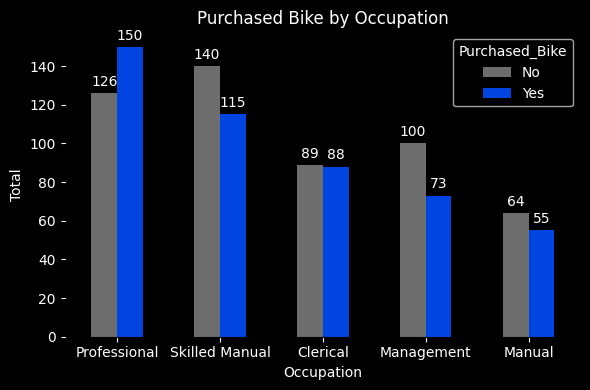

In [308]:
ax = CT_OccupationPB.drop(index='Total', columns='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total")
plt.title("Purchased Bike by Occupation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [309]:
CT_Occupation_Percent = (pd.crosstab(
    dfc['Occupation'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_Occupation_Percent.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes
Occupation,,
Professional,45.65,54.35
Clerical,50.28,49.72
Total,51.90,48.10
Manual,53.78,46.22
Skilled Manual,54.90,45.10
Management,57.80,42.20


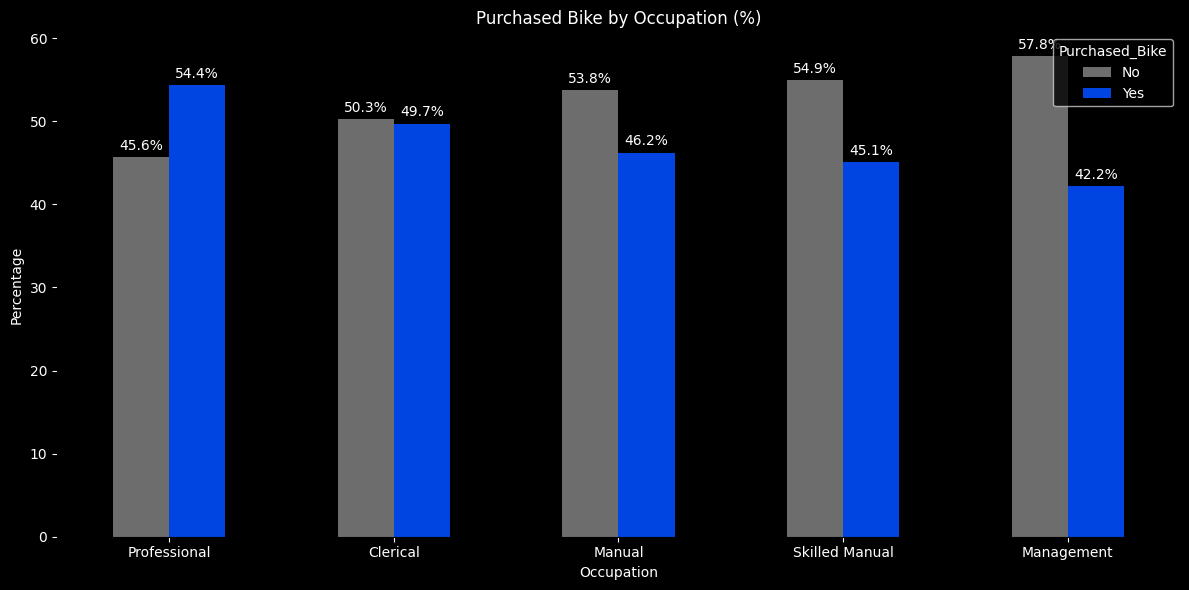

In [310]:
ax = CT_Occupation_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(12,6),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Occupation (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [311]:
Group_OccupationPB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Occupation')
    .size()
    .reset_index(name='Total_Buyers')
    .sort_values(by='Total_Buyers', ascending=False)
)

Group_OccupationPB.sort_values(by='Total_Buyers', ascending=False)

,Occupation,Total_Buyers
3,Professional,150
4,Skilled Manual,115
0,Clerical,88
1,Management,73
2,Manual,55


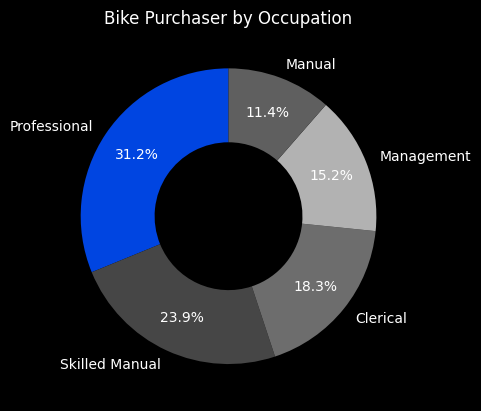

In [312]:
Pie_OccupationPB = dfc[dfc['Purchased_Bike'] == 'Yes']["Occupation"].value_counts()
plt.pie(
    Pie_OccupationPB,
    labels= Pie_OccupationPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.75,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Occupation')
plt.show()

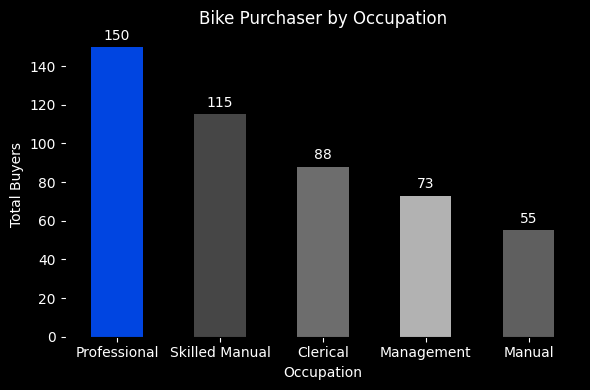

In [313]:
ax = Pie_OccupationPB.drop(columns='Total').plot(
    kind='bar',
    figsize=(6,4),
    color=[ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.0f', 
        padding=3
        )

plt.ylabel("Total Buyers")
plt.title("Bike Purchaser by Occupation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [314]:
CT_Region_Percent = (pd.crosstab(
    dfc['Region'],
    dfc['Purchased_Bike'],
    margins=True,
    margins_name='Total',
    normalize='index'
    )*100).round(2)

CT_Region_Percent.sort_values(by='Yes', ascending=False)

Purchased_Bike,No,Yes
Region,,
Pacific,41.15,58.85
Europe,50.67,49.33
Total,51.90,48.10
North America,56.69,43.31


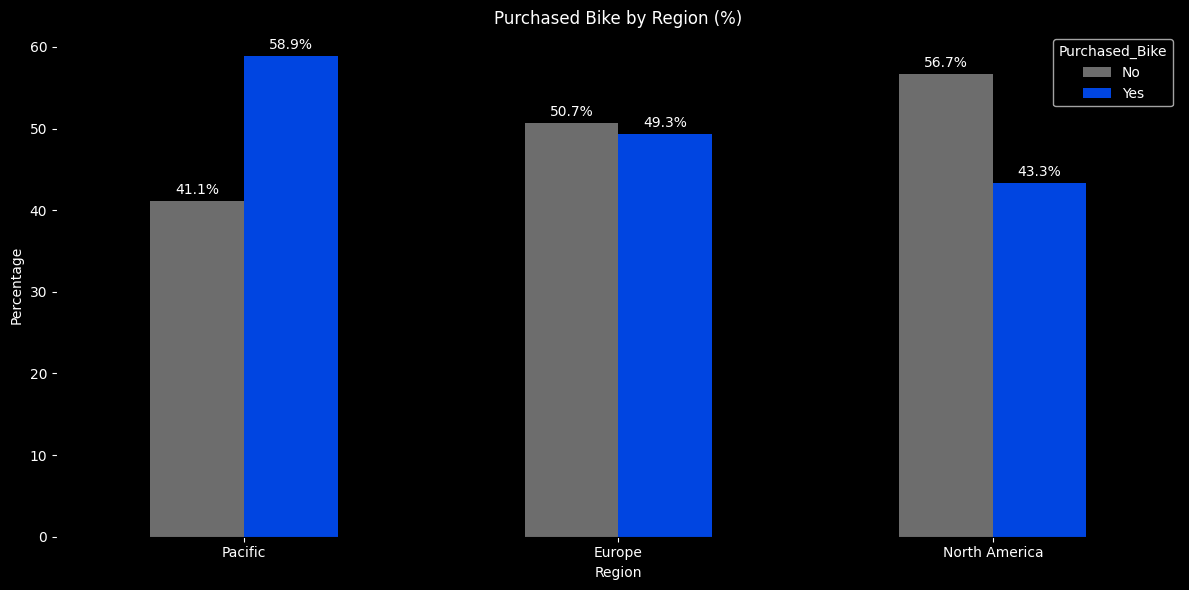

In [315]:
ax = CT_Region_Percent.drop(index='Total').sort_values(by='Yes', ascending=False).plot(
    kind='bar',
    figsize=(12,6),
    color=["#6D6D6D", "#0045e1"]
)

for c in ax.containers:
    ax.bar_label(
        c, 
        fmt='%.1f%%', 
        padding=3
        )

plt.ylabel("Percentage")
plt.title("Purchased Bike by Region (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [316]:
Group_RegionPB = (
    dfc[dfc['Purchased_Bike'] == 'Yes']
    .groupby('Region')
    .size()
    .reset_index(name='Total_Buyers')
    .sort_values(by='Total_Buyers', ascending=False)
)

Group_RegionPB.sort_values(by='Total_Buyers', ascending=False)

,Region,Total_Buyers
1,North America,220
0,Europe,148
2,Pacific,113


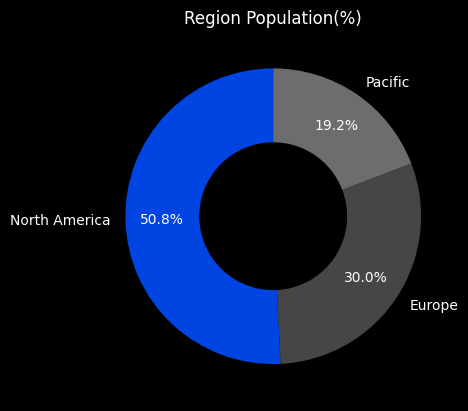

In [317]:
Pie_RegionPB = dfc["Region"].value_counts()
plt.pie(
    Pie_RegionPB,
    labels= Pie_RegionPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.75,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Region Population(%)')
plt.show()

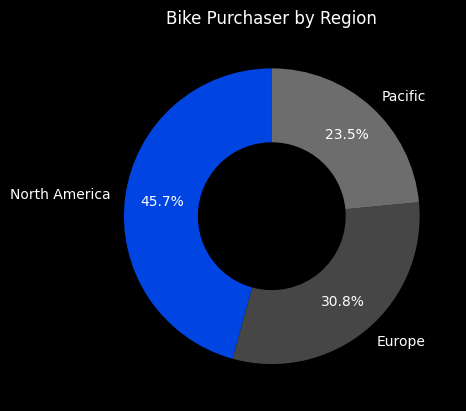

In [318]:
Pie_RegionPB = dfc[dfc['Purchased_Bike'] == 'Yes']["Region"].value_counts()
plt.pie(
    Pie_RegionPB,
    labels= Pie_RegionPB.index,
    autopct= "%1.1f%%",
    pctdistance=0.75,
    wedgeprops=dict(width= 0.5),
    startangle= 90,
    colors= [ '#0045e1', "#464646", "#6D6D6D", "#B2B2B2", "#5F5F5F"]
    )

plt.title('Bike Purchaser by Region')
plt.show()

In [319]:
dfc[
    (dfc['Car_Owner']=='No') & 
    (dfc['Commute_Distance']=='2-5 Miles') & 
    ((dfc['Income_Category']=='Middle') | (dfc['Income_Category']=='Ultra High')) & 
    ((dfc['Education']=='Bachelors') | (dfc['Education']=='Graduate Degree')) & 
    (dfc['Age_Group']=='Middle Aged')
    ].describe()

,ID,Income,Children,Cars,Age
count,30.000000,30.000000,30.000000,30.0,30.000000
mean,19159.933333,65666.666667,2.100000,0.0,37.366667
std,5908.888331,13565.507307,1.295882,0.0,3.872835
min,11738.000000,50000.000000,0.000000,0.0,34.000000
25%,13283.000000,60000.000000,1.000000,0.0,35.000000
50%,18848.500000,60000.000000,2.000000,0.0,36.000000
75%,24405.000000,70000.000000,3.000000,0.0,38.750000
max,28672.000000,130000.000000,4.000000,0.0,48.000000
